# Installing Dependencies

The HMDA 2024 LAR file is ~665MB zipped. We use **gdown** to pull it directly
from Google Drive and duckdb to query it efficiently without loading all 99
columns into pandas memory at once.

In [1]:
# Install required libraries
# gdown: download files from Google Drive
# duckdb: fast in-process SQL engine used to query the large HMDA file
#         without loading all 99 columns into memory at once
%pip install -q gdown duckdb
%pip install pandas numpy matplotlib scikit-learn lifelines

import gdown        # Google Drive downloader
import zipfile      # unzip the downloaded archive
import duckdb       # SQL query engine for large file handling
import os           # file path oper ations
import pandas as pd # dataframe manipulation
import warnings
warnings.filterwarnings('ignore')

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Downloading HMDA Data from Public Google Drive

The 2024 HMDA Loan Application Register (LAR) is downloaded from a shared
Google Drive link. The file is pipe-delimited (`|`) and contains one row per
loan application across all covered institutions nationally.
Download takes approximately 1 minute.

In [2]:
# Download HMDA 2024 LAR from Google Drive
# Source: https://ffiec.cfpb.gov/data-publication/dynamic-national-loan-level-dataset/2024
file_id = "1TwuI1Fph0wSY60l6AqjHgvzSyuho2IpE"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "data.zip", quiet=False)

# Unzip to local Colab storage
# Extracting locally is faster than reading repeatedly from Drive
with zipfile.ZipFile("data.zip", "r") as zip_ref:
    zip_ref.extractall("data")

# Locate the extracted .txt file
# The zip contains a single pipe-delimited .txt file
hmda_file = None
for root, dirs, files in os.walk("data"):
    for f in files:
        if f.endswith(".txt"):
            hmda_file = os.path.join(root, f)

print(f"Using file: {hmda_file}")

Downloading...
From (original): https://drive.google.com/uc?id=1TwuI1Fph0wSY60l6AqjHgvzSyuho2IpE
From (redirected): https://drive.google.com/uc?id=1TwuI1Fph0wSY60l6AqjHgvzSyuho2IpE&confirm=t&uuid=c28c0114-7f95-448b-b1f2-4ad01217e751
To: /Users/nickbotti/Downloads/data.zip
100%|████████████████████████████████████████| 665M/665M [00:12<00:00, 53.4MB/s]


Using file: data/2024_lar.txt


# Checking the Schema

Before selecting features we inspect the full column list. The HMDA LAR has
99 columns covering loan characteristics, applicant demographics, geographic
identifiers, and post-decision fields. We use DuckDB to load only a 10,000
row sample for schema inspection without loading the full dataset into memory.

In [3]:
# Connect DuckDB in-process
# DuckDB reads the pipe-delimited file directly via SQL
# all_varchar=True reads every column as string to avoid type inference errors
# on mixed-format fields like debt_to_income_ratio ('30%-<36%', '42', 'Exempt')
con = duckdb.connect()

# Load 10,000 rows for schema inspection only
df = con.execute(f"""
SELECT *
FROM read_csv_auto(
    '{hmda_file}',
    delim='|',
    all_varchar=True
)
LIMIT 10000
""").fetchdf()

print(f"Loaded {len(df):,} rows and {len(df.columns)} columns.")

# Print all column names to inform feature selection
print("\nAll columns:")
for i, col in enumerate(df.columns):
    print(f"{i:3}. {col}")

Loaded 10,000 rows and 99 columns.

All columns:
  0. activity_year
  1. lei
  2. derived_msa_md
  3. state_code
  4. county_code
  5. census_tract
  6. conforming_loan_limit
  7. derived_loan_product_type
  8. derived_dwelling_category
  9. derived_ethnicity
 10. derived_race
 11. derived_sex
 12. action_taken
 13. purchaser_type
 14. preapproval
 15. loan_type
 16. loan_purpose
 17. lien_status
 18. reverse_mortgage
 19. open_end_line_of_credit
 20. business_or_commercial_purpose
 21. loan_amount
 22. combined_loan_to_value_ratio
 23. interest_rate
 24. rate_spread
 25. hoepa_status
 26. total_loan_costs
 27. total_points_and_fees
 28. origination_charges
 29. discount_points
 30. lender_credits
 31. loan_term
 32. prepayment_penalty_term
 33. intro_rate_period
 34. negative_amortization
 35. interest_only_payment
 36. balloon_payment
 37. other_nonamortizing_features
 38. property_value
 39. construction_method
 40. occupancy_type
 41. manufactured_home_secured_property_type
 42. ma

## Building the Modeling Dataset

We select features using DuckDB SQL directly from the raw file. This avoids
loading all 99 columns into memory. Feature selection follows three principles:

1. **No data leakage:** post-decision fields (denial_reason, origination_charges)
   are excluded because they are only known after the lending decision is made.
2. **Include underwriting signals:** loan details before approval decision, applicant financials,
   and census tract context available at time of application.
3. **Include protected attributes:** race, ethnicity, sex, and age are included
   for analysis but represent a governance risk if used directly as model features.

We load up to 10,000,000 rows to capture a representative national sample.

In [4]:
# Query selected columns from HMDA file via DuckDB
# Only the columns we need are loaded avoids RAM crash from loading all 99
#
# action_taken: target variable (values 1-8, filtered to 1 and 3 below)
# Loan characteristics: amount, property value, reverse mortage, type, purpose, DTI
# Applicant demographics: income, race (protected), ethnicity (protected), sex (protected), age (protected)
# Geography: derived_msa_md, ffiec_msa_md_median_family_income, state_code (proxy)
#
# WHERE action_taken IS NOT NULL removes rows with missing target
df_model = con.execute(f"""
SELECT
    action_taken,
    loan_purpose,
    state_code,
    property_value,
    reverse_mortgage,
    preapproval,
    submission_of_application,
    business_or_commercial_purpose,
    occupancy_type,
    derived_dwelling_category,
    income,
    debt_to_income_ratio,
    derived_ethnicity,
    derived_race,
    derived_sex,
    applicant_age,
    tract_population,
    construction_method,
    aus_1,
    ffiec_msa_md_median_family_income,

     CASE
        WHEN action_taken IN ('1', '2') THEN 1
        WHEN action_taken = '3' THEN 0
     END AS approved

FROM read_csv_auto(
    '{hmda_file}',
    delim='|',
    all_varchar=True
)
WHERE action_taken IS NOT NULL
AND action_taken IN ('1', '2', '3')
AND NOT (
    action_taken IN ('Exempt','NA','NaN','','8888') OR
    loan_purpose IN ('Exempt','NA','NaN','','8888') OR
    state_code IN ('Exempt','NA','NaN','','8888') OR
    property_value IN ('Exempt','NA','NaN','','8888') OR
    reverse_mortgage IN ('Exempt','NA','NaN','','8888') OR
    preapproval IN ('Exempt','NA','NaN','','8888') OR
    submission_of_application IN ('Exempt','NA','NaN','','8888') OR
    business_or_commercial_purpose IN ('Exempt','NA','NaN','','8888') OR
    occupancy_type IN ('Exempt','NA','NaN','','8888') OR
    derived_dwelling_category IN ('Exempt','NA','NaN','','8888') OR
    income IN ('Exempt','NA','NaN','','8888') OR
    debt_to_income_ratio IN ('Exempt','NA','NaN','','8888') OR
    derived_ethnicity IN ('Exempt','NA','NaN','','8888') OR
    derived_race IN ('Exempt','NA','NaN','','8888') OR
    derived_sex IN ('Exempt','NA','NaN','','8888') OR
    applicant_age IN ('Exempt','NA','NaN','','8888') OR
    tract_population IN ('Exempt','NA','NaN','','8888') OR
    construction_method IN ('Exempt','NA','NaN','','8888') OR
    aus_1 IN ('Exempt','NA','NaN','','8888') OR
    ffiec_msa_md_median_family_income IN ('Exempt','NA','NaN','','8888')
)
AND derived_sex NOT IN ('Joint', 'Sex Not Available')
""").df()
print(df_model.shape)
df_model.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(4319338, 21)


,action_taken,loan_purpose,state_code,property_value,reverse_mortgage,preapproval,submission_of_application,business_or_commercial_purpose,occupancy_type,derived_dwelling_category,...,debt_to_income_ratio,derived_ethnicity,derived_race,derived_sex,applicant_age,tract_population,construction_method,aus_1,ffiec_msa_md_median_family_income,approved
0,1,1,IN,285000,2,2,1,2,1,Single Family (1-4 Units):Manufactured,...,30%-<36%,Not Hispanic or Latino,White,Male,25-34,2528,2,1,81800,1
1,1,32,FL,425000,2,2,1,2,1,Single Family (1-4 Units):Site-Built,...,50%-60%,Hispanic or Latino,White,Female,45-54,7516,1,1,90400,1
2,3,1,GA,185000,2,2,1,2,1,Single Family (1-4 Units):Site-Built,...,50%-60%,Not Hispanic or Latino,Black or African American,Female,45-54,3329,1,1,100900,0
3,1,1,NJ,575000,2,2,2,2,1,Single Family (1-4 Units):Site-Built,...,49,Not Hispanic or Latino,Black or African American,Male,55-64,5513,1,6,117400,1
4,1,1,TX,455000,2,2,2,2,1,Single Family (1-4 Units):Site-Built,...,46,Not Hispanic or Latino,Asian,Male,35-44,2144,1,2,110300,1


## Analyzing Target Variable Distribution

Before filtering we inspect the full distribution of action_taken to understand
how many applications fall into each outcome. Values 1-8 cover the full application
lifecycle. We keep only originated (1) and denied (3) for a clean binary problem.

In [5]:
# Inspect action_taken distribution before filtering
# action_taken values:
# 1 = Loan originated          -- keep, label = 1 (approved)
# 2 = Approved but not accepted -- excluded (ambiguous, applicant declined)
# 3 = Application denied        -- keep, label = 0 (denied)
# 4 = Withdrawn by applicant    -- excluded (no lender decision made)
# 5 = File closed incomplete    -- excluded (no lender decision made)
# 6 = Purchased loan            -- excluded (post-origination, not an application)
# 7 = Preapproval denied        -- excluded (preapproval, not a full application)
# 8 = Preapproval approved      -- excluded (preapproval, not a full application)
df_model['action_taken'].value_counts(dropna=False)

action_taken
1    3029003
3    1113020
2     177315
Name: count, dtype: int64

## Creating Binary Target Variable (Approved vs Denied)

We filter to action_taken = 1 (originated), action_taken = 2, and action_taken = 3 (denied) only.
This gives a clean binary classification problem -- did the lender make a
favorable (approved) or unfavorable (denied) decision?

Note: action_taken values are strings because we used all_varchar=True
in DuckDB, so we map **'1'**, **'2'**, and **'3'** rather than integers.

In [6]:
# Confirm label distribution -- expect significant imbalance (approvals >> denials)
df_model['approved'].value_counts()

approved
1    3206318
0    1113020
Name: count, dtype: int64

## Merging Ethnicity and Race Columns and Cleaning Sex Column

In [7]:
#Merge the columns, then clean columns. First, find out what each variable looks like.
print("\nethnicity categories:")
print(df_model['derived_ethnicity'].unique())

print("\nrace categories:")
print(df_model['derived_race'].unique())


ethnicity categories:
['Not Hispanic or Latino' 'Hispanic or Latino' 'Ethnicity Not Available'
 'Joint' 'Free Form Text Only']

race categories:
['White' 'Black or African American' 'Asian' 'Race Not Available'
 'American Indian or Alaska Native' 'Joint'
 'Native Hawaiian or Other Pacific Islander' '2 or more minority races'
 'Free Form Text Only']


In [8]:
df_model['race'] = df_model['derived_race']

df_model.loc[
    (
        (df_model['derived_race'] == "White") |
        (df_model['derived_race'] == "Race Not Available")
    ) &
    (df_model['derived_ethnicity'] == "Hispanic or Latino"),
    'race'
] = "Hispanic or Latino"

df_model.loc[df_model['race'] == "White", 'race'] = "White (Non-Hispanic)"

drop_vals = [
    "2 or more minority races",
    "Free Form Text Only",
    "Joint",
    "Race Not Available"
]

mask = ~df_model['race'].isin(drop_vals)

df_model = df_model.loc[mask].copy()

print("\nrace categories:")
print(df_model['race'].unique())
print("\nrace counts:")
print(df_model['race'].value_counts())


race categories:
['White (Non-Hispanic)' 'Hispanic or Latino' 'Black or African American'
 'Asian' 'American Indian or Alaska Native'
 'Native Hawaiian or Other Pacific Islander']

race counts:
race
White (Non-Hispanic)                         2446879
Hispanic or Latino                            609150
Black or African American                     526506
Asian                                         319323
American Indian or Alaska Native               46767
Native Hawaiian or Other Pacific Islander      13839
Name: count, dtype: int64


## Converting Numeric Columns and Final Cleanup for Model Prediction

Several continuous fields were loaded as strings because of **all_varchar=True** in DuckDB. We coerce these to numeric using **errors='coerce'**, which converts any remaining non-standard strings to NaN. We then drop rows where conversion failed, removing any residual non-standard values not caught earlier.

In [9]:
#Map debt to income ratios to reflect numeric values
dti_map = {
    '<20%': 0.15,
    '20%-<30%': 0.25,
    '30%-<36%': 0.33,
    '36': 0.36,
    '37': 0.37,
    '38': 0.38,
    '39': 0.39,
    '40': 0.40,
    '41': 0.41,
    '42': 0.42,
    '43': 0.43,
    '44': 0.44,
    '45': 0.45,
    '46': 0.46,
    '47': 0.47,
    '48': 0.48,
    '49': 0.49,
    '50%-60%': 0.55,
    '>60%': 0.65
}

df_model['debt_to_income_ratio'] = df_model['debt_to_income_ratio'].map(dti_map)

# Define category order for 'derived_race' with 'White' as the reference
race_categories = ['White (Non-Hispanic)', 'Black or African American', 'Asian', 'American Indian or Alaska Native', 'Native Hawaiian or Other Pacific Islander', 'Hispanic or Latino']
df_model['race'] = df_model['race'].astype(pd.CategoricalDtype(categories=race_categories, ordered=True))

# Define category order for 'derived_sex' with 'Male' as the reference
sex_categories = ['Male', 'Female']
df_model['sex'] = df_model['derived_sex'].astype(pd.CategoricalDtype(categories=sex_categories, ordered=True))


#Step 2: The variables involved are selected and categorized
numeric_cols = [
    'income',                              # applicant gross annual income (thousands)
    'property_value',                      # The value of the property securing the covered loan, or, in the case of an application, proposed to secure the covered loan, relied on in making the credit decision
    'debt_to_income_ratio',                # the ratio, as a percentage, of the applicant's or borrower's total monthly debt to the total monthly income relied on in making the credit decision
    'ffiec_msa_md_median_family_income',   #FFIEC Median family income in dollars for the MSA/MD in which the tract is located

]

categorical_cols = [
    'loan_purpose',                   # The purpose of the covered loan or application
    'reverse_mortgage',               # whether the covered loan or application is for a reverse mortage (binary indicator)
    'submission_of_application',      # Whether the applicant or borrower submitted the application directly to the financial institution (binary indicator)
    'business_or_commercial_purpose', # Whether the covered loan or application is primarily for a business or commercial purpose
    'occupancy_type',                 # Occupancy Type for the dwelling: primary, second, investment property
    'construction_method'             # Construction method for the dwelling
]

protected_attrs = [
    'race',               # PROTECTED ATTRIBUTE -- governance risk if used as feature
    'sex',                # PROTECTED ATTRIBUTE -- governance risk if used as feature
    'applicant_age',
    'state_code'
]

#Step 3: clean data
for col in numeric_cols:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

for col in categorical_cols:
    df_model[col] = df_model[col].astype('category')

# Drop rows where numeric conversion failed
# Any row still containing NaN had a non-standard value not caught earlier
model_features = numeric_cols + categorical_cols
df_model = df_model.dropna(subset=model_features)

print(df_model.shape)
df_model.head()

(3962464, 23)


,action_taken,loan_purpose,state_code,property_value,reverse_mortgage,preapproval,submission_of_application,business_or_commercial_purpose,occupancy_type,derived_dwelling_category,...,derived_race,derived_sex,applicant_age,tract_population,construction_method,aus_1,ffiec_msa_md_median_family_income,approved,race,sex
0,1,1,IN,285000,2,2,1,2,1,Single Family (1-4 Units):Manufactured,...,White,Male,25-34,2528,2,1,81800,1,White (Non-Hispanic),Male
1,1,32,FL,425000,2,2,1,2,1,Single Family (1-4 Units):Site-Built,...,White,Female,45-54,7516,1,1,90400,1,Hispanic or Latino,Female
2,3,1,GA,185000,2,2,1,2,1,Single Family (1-4 Units):Site-Built,...,Black or African American,Female,45-54,3329,1,1,100900,0,Black or African American,Female
3,1,1,NJ,575000,2,2,2,2,1,Single Family (1-4 Units):Site-Built,...,Black or African American,Male,55-64,5513,1,6,117400,1,Black or African American,Male
4,1,1,TX,455000,2,2,2,2,1,Single Family (1-4 Units):Site-Built,...,Asian,Male,35-44,2144,1,2,110300,1,Asian,Male


## Splitting Data into Training and Testing Sets

We use an 80/20 train/test split with **random_state=42** for reproducibility.
The test set is held out entirely and used only for final model evaluation.

Given the class imbalance (approvals >> denials), we use **stratify=y** to ensure both splits have the same approval rate, preventing the model from training on a different class distribution than it is evaluated on

In [10]:
from sklearn.model_selection import train_test_split

# Build feature matrix X and target vector y
# Removed 'race', 'sex' from drop list to include them in the model
X = df_model.drop(columns=['approved', 'action_taken', 'race', 'sex', 'applicant_age', 'state_code'])
y = df_model['approved']

# Train/test split -- 80% train, 20% test
# random_state=42 ensures reproducibility across runs
# Consider stratify=y given class imbalance (approvals >> denials)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(3169971, 17) (792493, 17)


In [11]:
print(y_train.value_counts())
print(y_test.value_counts())

approved
1    2358796
0     811175
Name: count, dtype: int64
approved
1    589699
0    202794
Name: count, dtype: int64


## Demographic Breakdown

Let's examine the composition of the data before evaluating the fairness.

In [12]:
#See how many observations are allocated to different age categories
df_model["applicant_age"].value_counts()

applicant_age
35-44    960908
45-54    854009
25-34    803855
55-64    662926
65-74    365019
<25      164690
>74      151057
Name: count, dtype: int64

In [13]:
#See how many observations are allocated to different race categories
df_model["race"].value_counts()

race
White (Non-Hispanic)                         2446879
Hispanic or Latino                            609150
Black or African American                     526506
Asian                                         319323
American Indian or Alaska Native               46767
Native Hawaiian or Other Pacific Islander      13839
Name: count, dtype: int64

In [14]:
#Using the counts above, figure out the percentage of the observations
total_applicants = len(df_model)

print("White applicants: %.2f%%" % (len(df_model[df_model['race'] == 'White (Non-Hispanic)']) / total_applicants * 100))
print("Hispanic or Latino applicants: %.2f%%" % (len(df_model[df_model['race'] == 'Hispanic or Latino']) / total_applicants * 100))
print("Black or African American applicants: %.2f%%" % (len(df_model[df_model['race'] == 'Black or African American']) / total_applicants * 100))
print("Asian applicants: %.2f%%" % (len(df_model[df_model['race'] == 'Asian']) / total_applicants * 100))
print("American Indian or Alaska Native applicants: %.2f%%" % (len(df_model[df_model['race'] == 'American Indian or Alaska Native']) / total_applicants * 100))
print("Native Hawaiian or Other Pacific Islander applicants: %.2f%%" % (len(df_model[df_model['race'] == 'Native Hawaiian or Other Pacific Islander']) / total_applicants * 100))

White applicants: 61.75%
Hispanic or Latino applicants: 15.37%
Black or African American applicants: 13.29%
Asian applicants: 8.06%
American Indian or Alaska Native applicants: 1.18%
Native Hawaiian or Other Pacific Islander applicants: 0.35%


In [15]:
#See how many observations are allocated to different sex categories
df_model["sex"].value_counts()

sex
Male      2364883
Female    1597581
Name: count, dtype: int64

In [16]:
#Using the counts above, figure out the percentage of the observations
total_applicants = len(df_model)

print("Male applicants: %.2f%%" % (len(df_model[df_model['sex'] == 'Male']) / total_applicants * 100))
print("Female applicants: %.2f%%" % (len(df_model[df_model['sex'] == 'Female']) / total_applicants * 100))

Male applicants: 59.68%
Female applicants: 40.32%


In [17]:
#Construct a crosstab that shows the allocation of observations between sex and race
pd.crosstab(df_model['sex'], df_model['race'])

race,White (Non-Hispanic),Black or African American,Asian,American Indian or Alaska Native,Native Hawaiian or Other Pacific Islander,Hispanic or Latino
sex,,,,,,
Male,1486333,245815,212723,28494,8778,382740
Female,960546,280691,106600,18273,5061,226410


### Overall Approval Rating Analysis

In [18]:
#Show how many observations were accepted
len(df_model[df_model["approved"] == 1])

2948495

In [19]:
#Find Approval Rate
len(df_model[df_model["approved"] == 1]) / len(df_model) * 100

74.41064448787421

# Building Model

In [20]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Separate numeric and categorical columns
X_train_numeric = X_train[numeric_cols]
X_train_categorical = X_train[categorical_cols]
X_test_numeric = X_test[numeric_cols]
X_test_categorical = X_test[categorical_cols]

# Initialize and apply StandardScaler to numeric features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_numeric), index=X_train_numeric.index, columns=X_train_numeric.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_numeric), index=X_test_numeric.index, columns=X_test_numeric.columns)

# Initialize and apply OneHotEncoder to categorical features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_encoded = pd.DataFrame(encoder.fit_transform(X_train_categorical), index=X_train_categorical.index, columns=encoder.get_feature_names_out(categorical_cols))
X_test_encoded = pd.DataFrame(encoder.transform(X_test_categorical), index=X_test_categorical.index, columns=encoder.get_feature_names_out(categorical_cols))

# Concatenate scaled numeric and encoded categorical features
X_train = pd.concat([X_train_scaled, X_train_encoded], axis=1)
X_test = pd.concat([X_test_scaled, X_test_encoded], axis=1)

print(X_train.shape, X_test.shape)
print(X_train.head())

(3169971, 24) (792493, 24)
           income  property_value  debt_to_income_ratio  \
2716490 -0.005634       -0.080905             -0.023349   
1240283 -0.001903       -0.021696             -0.661029   
4308660 -0.002151        0.052314             -2.095809   
3285792 -0.006691       -0.121611             -0.023349   
1657562 -0.002338       -0.103108             -0.262479   

         ffiec_msa_md_median_family_income  loan_purpose_1  loan_purpose_2  \
2716490                          -1.308823             1.0             0.0   
1240283                           0.634602             1.0             0.0   
4308660                          -0.427990             0.0             0.0   
3285792                          -1.001231             1.0             0.0   
1657562                          -0.838113             0.0             0.0   

         loan_purpose_31  loan_purpose_32  loan_purpose_4  loan_purpose_5  \
2716490              0.0              0.0             0.0             0.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
import joblib

# -----------------------------
# Threshold (single source of truth)
# -----------------------------
THRESHOLD = 0.8

# If the model does not exist, train and save it
rf_pipeline = Pipeline([
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        max_depth = 15,
        min_samples_leaf=10
    ))
])

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.-

In [22]:
# -----------------------------
# Evaluation function (clean)
# -----------------------------
def group_metrics(pipeline, X, y, df_model, group_col="race", threshold=THRESHOLD):
    X_ = X.copy()

    probs = pipeline.predict_proba(X)[:, 1]
    preds = (probs >= threshold).astype(int)

    X_["pred"] = preds
    X_["pred_prob"] = probs
    X_["actual"] = y.values
    X_[group_col] = df_model.loc[X.index, group_col]

    results = []

    for group, gdf in X_.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(gdf["actual"], gdf["pred"]).ravel()

        results.append({
            group_col: group,
            "n": len(gdf),
            "accuracy": round(accuracy_score(gdf["actual"], gdf["pred"]), 3),
            "FPR": round(fp / (fp + tn), 3) if (fp + tn) > 0 else 0,
            "FNR": round(fn / (fn + tp), 3) if (fn + tp) > 0 else 0,
            "AUC": round(roc_auc_score(gdf["actual"], gdf["pred_prob"]), 3),
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

print("Random Forest")
print(group_metrics(rf_pipeline, X_test, y_test, df_model, "race"))

Random Forest
                                        race       n  accuracy    FPR    FNR  \
0                       White (Non-Hispanic)  489463     0.658  0.151  0.397   
5                         Hispanic or Latino  121968     0.741  0.195  0.286   
1                  Black or African American  105171     0.705  0.173  0.364   
2                                      Asian   63915     0.805  0.234  0.184   
3           American Indian or Alaska Native    9207     0.707  0.127  0.387   
4  Native Hawaiian or Other Pacific Islander    2769     0.673  0.163  0.427   

     AUC  
0  0.839  
5  0.852  
1  0.835  
2  0.869  
3  0.857  
4  0.832  


In [23]:
import pandas as pd
from sklearn.metrics import (confusion_matrix,
                            accuracy_score,
                            roc_auc_score)

def group_metrics(pipeline, X, y, group_col="ex"):
    results = []
    X_ = X.copy()

    probs = pipeline.predict_proba(X)[:, 1]
    preds = (probs >= THRESHOLD).astype(int)

    # Make predictions using only the features the pipeline was trained on
    X_["pred"] = preds
    X_["pred_prob"] = probs

    # Add 'actual' and the group_col after predictions are made
    X_["actual"] = y.values
    X_["sex"] = df_model.loc[X_test.index, 'sex']

    for group, gdf in X_.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(
            gdf['actual'], gdf['pred']
        ).ravel()
        results.append({
            "sex": group,
            "n": len(gdf),
            "accuracy": round(accuracy_score(
                gdf["actual"], gdf["pred"]), 3),
            "FPR": round(fp / (fp + tn), 3),
            "FNR": round(fn / (fn + tp), 3),
            "AUC": round(roc_auc_score(
                gdf["actual"], gdf["pred_prob"]), 3),
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

print("Random Forest")
# Call group_metrics with X_test directly and specify the group_col
print(group_metrics(rf_pipeline, X_test, y_test, group_col='sex'))

Random Forest
      sex       n  accuracy    FPR    FNR    AUC
0    Male  472768     0.692  0.181  0.350  0.836
1  Female  319725     0.687  0.152  0.373  0.852


# LIME Analysis

LIME can be used to understand why a model made a specific prediction, and what features are used prominently to get to that prediction. This is done by picking a data point, and understand why the person was approved or not approved for a loan. However, this is a local only process, and does not explain the entire model, and, it can be unstable due to small changes in data leading to different explanations. Therefore, it must be paired with a more global approach, like SHAP to evaluate further. Still, LIME can reveal interesting insights...

In [24]:
%pip install lime

Note: you may need to restart the kernel to use updated packages.


In [25]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

# Use RAW training data (NOT transformed)
X_train_lime = X_train.copy()

explainer = LimeTabularExplainer(
    training_data=X_train_lime.values,
    feature_names=X_train.columns.tolist(),
    class_names=["Not Approved", "Approved"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

def predict_rf(data):
    return rf_pipeline.predict_proba(pd.DataFrame(data, columns=X_train.columns))

X_test_copy = X_test.copy()

X_test_copy["pred_prob"] = rf_pipeline.predict_proba(X_test)[:, 1]

black_df = X_test_copy[df_model.loc[X_test.index, "race"] == "Black or African American"].sort_values("pred_prob")
white_df = X_test_copy[df_model.loc[X_test.index, "race"] == "White (Non-Hispanic)"].sort_values("pred_prob")

black_idx = black_df.index[len(black_df) // 2]
white_idx = white_df.index[len(white_df) // 2]

models = {
    "Random Forest": predict_rf
}

for model_name, predict_fn in models.items():
    print("\n" + "="*60)
    print(f"LIME: {model_name}")
    print("="*60)

    for label, idx in [("Black applicant", black_idx),
                       ("White applicant", white_idx)]:

        row = X_test.loc[[idx]].values

        exp = explainer.explain_instance(
            data_row=row[0],
            predict_fn=predict_fn,
            num_features=6
        )

        prob = predict_fn(row)[0][1]

        print(f"\n{label}")
        print(f"Predicted probability: {prob:.3f}")

        for feat, weight in exp.as_list():
            print(f"{feat:<40} {weight:+.4f}")


LIME: Random Forest

Black applicant
Predicted probability: 0.784
loan_purpose_1 <= 0.00                   -0.1497
debt_to_income_ratio <= -0.66            +0.0866
loan_purpose_4 <= 0.00                   +0.0761
loan_purpose_2 <= 0.00                   +0.0724
construction_method_2 <= 0.00            +0.0600
-0.00 < income <= -0.00                  +0.0408

White applicant
Predicted probability: 0.801
loan_purpose_1 <= 0.00                   -0.1412
debt_to_income_ratio <= -0.66            +0.0857
loan_purpose_4 <= 0.00                   +0.0755
construction_method_2 <= 0.00            +0.0725
loan_purpose_2 <= 0.00                   +0.0645
-0.00 < income <= -0.00                  +0.0345


In [26]:
from lime.lime_tabular import LimeTabularExplainer
import pandas as pd

# -----------------------------
# LIME setup (unchanged)
# -----------------------------
X_train_lime = X_train.copy()

explainer = LimeTabularExplainer(
    training_data=X_train_lime.values,
    feature_names=X_train.columns.tolist(),
    class_names=["Not Approved", "Approved"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

def predict_rf(data):
    return rf_pipeline.predict_proba(pd.DataFrame(data, columns=X_train.columns))

models = {
    "Random Forest": predict_rf
}

# -----------------------------
# score full test set ONCE (important)
# -----------------------------
X_test_copy = X_test.copy()
X_test_copy["rf_prob"] = rf_pipeline.predict_proba(X_test)[:, 1]

race_col = df_model.loc[X_test.index, "race"]
X_test_copy["race"] = race_col.values

# -----------------------------
# helper to pick 4 indices
# -----------------------------
def pick_cases(df):
    return {
        "Most Approved": df.sort_values("rf_prob", ascending=False).index[0],
        "Least Approved": df.sort_values("rf_prob", ascending=True).index[0]
    }

black_df = X_test_copy[X_test_copy["race"] == "Black or African American"]
white_df = X_test_copy[X_test_copy["race"] == "White (Non-Hispanic)"]

black_cases = pick_cases(black_df)
white_cases = pick_cases(white_df)

# -----------------------------
# LIME LOOP
# -----------------------------
for model_name, predict_fn in models.items():
    print("\n" + "="*70)
    print(f"LIME: {model_name}")
    print("="*70)

    for group_name, cases in [
        ("Black applicant", black_cases),
        ("White applicant", white_cases)
    ]:
        for case_label, idx in cases.items():

            row = X_test.loc[[idx]].values

            exp = explainer.explain_instance(
                data_row=row[0],
                predict_fn=predict_fn,
                num_features=6
            )

            prob = predict_fn(row)[0][1]

            print(f"\n{group_name} — {case_label}")
            print(f"Predicted probability: {prob:.3f}")

            for feat, weight in exp.as_list():
                print(f"{feat:<40} {weight:+.4f}")


LIME: Random Forest

Black applicant — Most Approved
Predicted probability: 0.947
0.00 < loan_purpose_1 <= 1.00            +0.1509
debt_to_income_ratio <= -0.66            +0.0870
loan_purpose_4 <= 0.00                   +0.0768
loan_purpose_2 <= 0.00                   +0.0755
construction_method_2 <= 0.00            +0.0600
-0.04 < property_value <= 0.03           +0.0402

Black applicant — Least Approved
Predicted probability: 0.021
debt_to_income_ratio > 0.61              -0.3150
loan_purpose_1 <= 0.00                   -0.1413
income <= -0.01                          -0.0924
loan_purpose_4 <= 0.00                   +0.0751
loan_purpose_2 > 0.00                    -0.0660
property_value <= -0.08                  -0.0580

White applicant — Most Approved
Predicted probability: 0.954
debt_to_income_ratio > 0.61              -0.3259
0.00 < loan_purpose_1 <= 1.00            +0.1451
income <= -0.01                          -0.1008
loan_purpose_4 <= 0.00                   +0.0833
construc

# SHAP Analysis

SHAP informs how each feature contributed to every prediction in a consistent way. It is plotted into a beeswarm plot to optimally see how each feature we used in the model is contributing to each prediction, both positively and negatively (approved vs. not approved). It shows what features are used most heavily in the predictions, and, if those features need to be cautioned against due to proxy discrimination stemming from our protected attributes that are not used in the model.

In [27]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import shap
import matplotlib.pyplot as plt

# -----------------------------
# RF model
# -----------------------------
rf_model = rf_pipeline["classifier"]

X_test_enc = X_test

# feature names (only valid if no preprocessing)
feature_names = X_test.columns.tolist()

# -----------------------------
# SHAP
# -----------------------------
explainer = shap.Explainer(rf_model, X_test_enc.sample(200, random_state=42))
shap_values = explainer(X_test_enc)

# -----------------------------
# Summary plot
# -----------------------------
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_enc,
    feature_names=feature_names,
    show=False
)
plt.title("SHAP Beeswarm Plot (Random Forest)")
plt.tight_layout()
plt.show()

# -----------------------------
# Add predictions + race
# -----------------------------
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = rf_pipeline.predict_proba(X_test)[:, 1]
X_test_copy["race"] = df_model.loc[X_test.index, "race"]

# -----------------------------
# Cases
# -----------------------------
black_df = X_test_copy[X_test_copy["race"] == "Black or African American"].sort_values("pred_prob")
white_df = X_test_copy[X_test_copy["race"] == "White (Non-Hispanic)"].sort_values("pred_prob")

cases = [
    ("Black low risk", black_df.index[0]),
    ("Black high risk", black_df.index[-1]),
   ("White low risk", white_df.index[0]),
    ("White high risk", white_df.index[-1])
]

# -----------------------------
# Waterfall plots
# -----------------------------
for label, idx in cases:
    loc = X_test.index.get_loc(idx)

plt.figure()
shap.plots.waterfall(
        shap_values[loc],
        max_display=8,
        show=False
    )

plt.title(f"SHAP: {label}")
plt.tight_layout()
plt.show()

# DiCE Analysis

In [29]:
%pip install dice_ml

Note: you may need to restart the kernel to use updated packages.


In [30]:
import dice_ml
from dice_ml import Dice
import pandas as pd

# -----------------------------
# Split by race
# -----------------------------
black_df = X_test_copy[X_test_copy["race"] == "Black or African American"].sort_values("rf_prob")
white_df = X_test_copy[X_test_copy["race"] == "White (Non-Hispanic)"].sort_values("rf_prob")

# -----------------------------
# Define DiCE indices
# -----------------------------
black_lowest_idx = black_df.index[0]    # Black applicant, lowest predicted approval (Not Approved)
black_highest_idx = black_df.index[-1]  # Black applicant, highest predicted approval (Approved)

white_lowest_idx = white_df.index[0]    # White applicant, lowest predicted approval (Not Approved)
white_highest_idx = white_df.index[-1]  # White applicant, highest predicted approval (Approved)

dice_data = dice_ml.Data(
    dataframe=pd.concat([X_train, y_train.rename('approved')], axis=1),
    continuous_features=X_train.select_dtypes(include=['float64','float32','int64']).columns.tolist(),
    outcome_name='approved'
)

dice_model = dice_ml.Model(
    model=rf_pipeline,
    backend="sklearn",
    model_type="classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")

for label, idx in [
    ("Black applicant (Approved)",     black_highest_idx),
    ("Black applicant (Not Approved)", black_lowest_idx),
    ("White applicant (Approved)",     white_highest_idx),
    ("White applicant (Not Approved)", white_lowest_idx),
]:
    query = X_test.loc[[idx]]
    print(f"\n--- DiCE Counterfactuals: {label} (Index: {idx}) ---")
    try:
        cf = exp_dice.generate_counterfactuals(
            query,
            total_CFs=3,
            desired_class="opposite",
            features_to_vary=["income", "debt_to_income_ratio",
                              "property_value", "ffiec_msa_md_median_family_income"],
            permitted_range={
                "income": [float(X_train["income"].min()), float(X_train["income"].max())],
                "debt_to_income_ratio": [float(X_train["debt_to_income_ratio"].min()),
                                         float(X_train["debt_to_income_ratio"].max())],
                "property_value": [float(X_train["property_value"].min()),
                                   float(X_train["property_value"].max())],
                "ffiec_msa_md_median_family_income": [
                    float(X_train["ffiec_msa_md_median_family_income"].min()),
                    float(X_train["ffiec_msa_md_median_family_income"].max())],
            }
        )
        cf.visualize_as_dataframe(show_only_changes=True)
    except Exception as e:
        print(f"  No counterfactuals found. Try expanding features_to_vary or permitted_range.")
        print(f"  Error: {e}")


--- DiCE Counterfactuals: Black applicant (Approved) (Index: 1745780) ---


100%|█████████████████████████████████████████████| 1/1 [00:17<00:00, 17.41s/it]

Query instance (original outcome : 1)


,income,property_value,debt_to_income_ratio,ffiec_msa_md_median_family_income,loan_purpose_1,loan_purpose_2,loan_purpose_31,loan_purpose_32,loan_purpose_4,loan_purpose_5,...,submission_of_application_2,business_or_commercial_purpose_1,business_or_commercial_purpose_1111,business_or_commercial_purpose_2,occupancy_type_1,occupancy_type_2,occupancy_type_3,construction_method_1,construction_method_2,approved
0,0.005623,-0.017996,-0.661029,1.123953,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1



Diverse Counterfactual set (new outcome: 0)


,income,property_value,debt_to_income_ratio,ffiec_msa_md_median_family_income,loan_purpose_1,loan_purpose_2,loan_purpose_31,loan_purpose_32,loan_purpose_4,loan_purpose_5,...,submission_of_application_2,business_or_commercial_purpose_1,business_or_commercial_purpose_1111,business_or_commercial_purpose_2,occupancy_type_1,occupancy_type_2,occupancy_type_3,construction_method_1,construction_method_2,approved
0,782.8029007274,-,1.5085045,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
1,-,-,1.2683279,-2.06523728,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
2,838.8867630421,-,1.0246331,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0



--- DiCE Counterfactuals: Black applicant (Not Approved) (Index: 2789895) ---


100%|█████████████████████████████████████████████| 1/1 [00:10<00:00, 10.32s/it]

Query instance (original outcome : 0)


,income,property_value,debt_to_income_ratio,ffiec_msa_md_median_family_income,loan_purpose_1,loan_purpose_2,loan_purpose_31,loan_purpose_32,loan_purpose_4,loan_purpose_5,...,submission_of_application_2,business_or_commercial_purpose_1,business_or_commercial_purpose_1111,business_or_commercial_purpose_2,occupancy_type_1,occupancy_type_2,occupancy_type_3,construction_method_1,construction_method_2,approved
0,-0.00806,-0.103108,1.889691,-0.320799,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0



Diverse Counterfactual set (new outcome: 1)


,income,property_value,debt_to_income_ratio,ffiec_msa_md_median_family_income,loan_purpose_1,loan_purpose_2,loan_purpose_31,loan_purpose_32,loan_purpose_4,loan_purpose_5,...,submission_of_application_2,business_or_commercial_purpose_1,business_or_commercial_purpose_1111,business_or_commercial_purpose_2,occupancy_type_1,occupancy_type_2,occupancy_type_3,construction_method_1,construction_method_2,approved
0,-,16.63096696,0.6899953,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,1.0
1,-,-,0.6154523,3.21880944,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,1.0
2,681.9461892561,-,-0.9448802,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,1.0



--- DiCE Counterfactuals: White applicant (Approved) (Index: 429619) ---


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  1.47it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec
  No counterfactuals found. Try expanding features_to_vary or permitted_range.
  Error: No counterfactuals found for any of the query points! Kindly check your configuration.

--- DiCE Counterfactuals: White applicant (Not Approved) (Index: 3885877) ---


100%|█████████████████████████████████████████████| 1/1 [00:10<00:00, 10.24s/it]

Query instance (original outcome : 0)


,income,property_value,debt_to_income_ratio,ffiec_msa_md_median_family_income,loan_purpose_1,loan_purpose_2,loan_purpose_31,loan_purpose_32,loan_purpose_4,loan_purpose_5,...,submission_of_application_2,business_or_commercial_purpose_1,business_or_commercial_purpose_1111,business_or_commercial_purpose_2,occupancy_type_1,occupancy_type_2,occupancy_type_3,construction_method_1,construction_method_2,approved
0,-0.008308,-0.058702,1.889691,-0.455953,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0



Diverse Counterfactual set (new outcome: 1)


,income,property_value,debt_to_income_ratio,ffiec_msa_md_median_family_income,loan_purpose_1,loan_purpose_2,loan_purpose_31,loan_purpose_32,loan_purpose_4,loan_purpose_5,...,submission_of_application_2,business_or_commercial_purpose_1,business_or_commercial_purpose_1111,business_or_commercial_purpose_2,occupancy_type_1,occupancy_type_2,occupancy_type_3,construction_method_1,construction_method_2,approved
0,-,-,-0.1614528,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,1.0
1,-,-,-1.3539084,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,1.0
2,-,356.57510925,0.0100452,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,1.0


# Disparate Impact Audit

The disparate impact audit evaluates whether the model we produces systemically produces different outcomes across demopgrahic groups (or in other words, our protected attributes). We want to assess the outcome fairness (who gets approved) and error fairness (who incorrectly gets approved or denied)

We use 3 metrics for group-level outcome disparities


*   Adverse Impact Ratio (AIR): compares the approval rate of a protected group to that of a reference
*   Standardized Mean Difference (SMD): measures the difference in approval rates between groups in standardized units

*  Marginal Effect (ME): estimates teh change in approval probability associated with belonging to a group

and we also use two error-based metrics


*   False Positive Rate (FPR): measures how often the model incorrectly approves applicants who should be denied
*   False Negative Rate (FNR): measures how often the model incorrectly denies qualified applicants




In [31]:
%pip install solas-ai
import pandas as pd, numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
import solas_disparity as sd

Note: you may need to restart the kernel to use updated packages.


## AIR, SMD, ME: Race

In [32]:
from statsmodels.stats.proportion import proportions_ztest

# Get predicted probabilities (NOT hard classes)
probs = rf_pipeline.predict_proba(X_test)[:, 1]

# Apply your desired threshold
test_preds = (probs >= 0.8).astype(int)

# Create a temporary data frame of the test set's race and predictions
df_test_results = df_model.loc[X_test.index].copy()
df_test_results['rf_pred'] = test_preds

# 3. Define groups
group_a = 'Black or African American'
group_b = 'White (Non-Hispanic)'

ns = df_test_results[df_test_results['race'].isin([group_a, group_b])].groupby('race')['rf_pred'].count()
events = df_test_results[df_test_results['race'].isin([group_a, group_b])].groupby('race')['rf_pred'].sum()

# 5. Run the z-test
# Note: we pass the values in the order of the 'groups' list
stat, pval = proportions_ztest([events[group_a], events[group_b]], [ns[group_a], ns[group_b]])

print(f"--- Random Forest Model Statistical Significance Test ({group_a} vs {group_b}) ---")
print(f"Approval Rate ({group_a}): {events[group_a]/ns[group_a]:.2%}")
print(f"Approval Rate ({group_b}): {events[group_b]/ns[group_b]:.2%}")
print(f"Z-statistic: {stat:.3f}")
print(f"P-value: {pval:.4f}")

--- Random Forest Model Statistical Significance Test (Black or African American vs White (Non-Hispanic)) ---
Approval Rate (Black or African American): 46.97%
Approval Rate (White (Non-Hispanic)): 50.13%
Z-statistic: -18.602
P-value: 0.0000


In [33]:
# Encode race categories into binary
race_dummies = pd.get_dummies(df_model['race'], prefix='is').astype(int)

# Attach these indicators
df_model = pd.concat([df_model, race_dummies], axis=1)

print("df with Racial Indicators:")
display(df_model[['race'] + race_dummies.columns.tolist()].head(10))

df with Racial Indicators:


,race,is_White (Non-Hispanic),is_Black or African American,is_Asian,is_American Indian or Alaska Native,is_Native Hawaiian or Other Pacific Islander,is_Hispanic or Latino
0,White (Non-Hispanic),1,0,0,0,0,0
1,Hispanic or Latino,0,0,0,0,0,1
2,Black or African American,0,1,0,0,0,0
3,Black or African American,0,1,0,0,0,0
4,Asian,0,0,1,0,0,0
5,Hispanic or Latino,0,0,0,0,0,1
7,White (Non-Hispanic),1,0,0,0,0,0
8,Hispanic or Latino,0,0,0,0,0,1
9,Black or African American,0,1,0,0,0,0
10,White (Non-Hispanic),1,0,0,0,0,0


In [34]:
protected_groups = ["is_Black or African American", "is_Asian", "is_American Indian or Alaska Native", "is_Native Hawaiian or Other Pacific Islander", "is_Hispanic or Latino"]
reference_groups = ["is_White (Non-Hispanic)", "is_White (Non-Hispanic)", "is_White (Non-Hispanic)", "is_White (Non-Hispanic)", "is_White (Non-Hispanic)"]
group_categories = ["race", "race", "race", "race", "race"]

print(f"Protected Groups: {protected_groups}")
print(f"Reference Groups: {reference_groups}")
print(f"Group Categories: {group_categories}")

Protected Groups: ['is_Black or African American', 'is_Asian', 'is_American Indian or Alaska Native', 'is_Native Hawaiian or Other Pacific Islander', 'is_Hispanic or Latino']
Reference Groups: ['is_White (Non-Hispanic)', 'is_White (Non-Hispanic)', 'is_White (Non-Hispanic)', 'is_White (Non-Hispanic)', 'is_White (Non-Hispanic)']
Group Categories: ['race', 'race', 'race', 'race', 'race']


In [35]:
import solas_disparity as sd
from IPython.display import display

# 1. Create a DataFrame for the test set to avoid data leakage
df_test_audit = df_model.loc[X_test.index].copy()

# 2. Generate your Random Forest model's predictions for the test set
# This is the critical step: we want to audit what the model *decided*
probs = rf_pipeline.predict_proba(X_test)[:, 1]
df_test_audit['rf_predictions'] = (probs >= 0.8).astype(int)

# 3. Define groups (assuming you already created the dummy 'is_' columns in df_model earlier)
protected_groups = [
    "is_Black or African American",
    "is_Asian",
    "is_American Indian or Alaska Native",
    "is_Native Hawaiian or Other Pacific Islander",
    "is_Hispanic or Latino"
]
reference_groups = ["is_White (Non-Hispanic)"] * len(protected_groups)
group_categories = ["race"] * len(protected_groups)

# 4. Run the Adverse Impact Ratio (AIR) audit on the PREDICTIONS
air_rf = sd.adverse_impact_ratio(
    group_data=df_test_audit,
    protected_groups=protected_groups,
    reference_groups=reference_groups,
    group_categories=group_categories,
    outcome=df_test_audit['rf_predictions'], # <-- Auditing the model's predictions
    sample_weight=None,
    air_threshold=0.80, # 80% Rule (Four-Fifths Rule)
    percent_difference_threshold=0,
)

print("--- Random Forest Model Adverse Impact Ratio (AIR) by Race ---")
display(air_rf.summary_table)

--- Random Forest Model Adverse Impact Ratio (AIR) by Race ---


,Reference Group,Group Category,Observations,Percent Missing,Total,Favorable,Percent Favorable,Percent Difference Favorable,AIR,P-Values,Practically Significant,Shortfall
Group,,,,,,,,,,,,
is_Black or African American,is_White (Non-Hispanic),race,792493,0.0,105171,49399,0.469702,0.031611,0.936944,3.280358e-77,No,NaN
is_Asian,is_White (Non-Hispanic),race,792493,0.0,63915,44008,0.688539,-0.187227,1.373473,0.000000e+00,No,NaN
is_American Indian or Alaska Native,is_White (Non-Hispanic),race,792493,0.0,9207,4042,0.439014,0.062299,0.875729,2.599953e-32,No,NaN
is_Native Hawaiian or Other Pacific Islander,is_White (Non-Hispanic),race,792493,0.0,2769,1155,0.417118,0.084195,0.832052,1.177243e-18,No,NaN
is_Hispanic or Latino,is_White (Non-Hispanic),race,792493,0.0,121968,68210,0.559245,-0.057932,1.115561,3.783132e-287,No,NaN
is_White (Non-Hispanic),,race,792493,0.0,489463,245374,0.501313,NaN,NaN,NaN,,NaN


In [36]:
smd = sd.standardized_mean_difference(
    group_data=df_test_audit,
    protected_groups=protected_groups,
    reference_groups=reference_groups,
    group_categories=group_categories,
    outcome=df_test_audit['rf_predictions'],
    smd_threshold=-20,
    lower_score_favorable=False
)
smd.summary_table

,Reference Group,Group Category,Observations,Percent Missing,Total,Average Outcome,Difference in Average Outcome,Std. Dev. of Outcomes,SMD,P-Values,Practically Significant
Group,,,,,,,,,,,
is_Black or African American,is_White (Non-Hispanic),race,792493,0.0,105171,0.469702,-0.031611,0.499596,-6.327306,2.929321e-77,No
is_Asian,is_White (Non-Hispanic),race,792493,0.0,63915,0.688539,0.187227,0.499596,37.475678,0.000000e+00,No
is_American Indian or Alaska Native,is_White (Non-Hispanic),race,792493,0.0,9207,0.439014,-0.062299,0.499596,-12.469862,2.271612e-32,No
is_Native Hawaiian or Other Pacific Islander,is_White (Non-Hispanic),race,792493,0.0,2769,0.417118,-0.084195,0.499596,-16.852547,9.899767e-19,No
is_Hispanic or Latino,is_White (Non-Hispanic),race,792493,0.0,121968,0.559245,0.057932,0.499596,11.595858,1.669055e-287,No
is_White (Non-Hispanic),,race,792493,0.0,489463,0.501313,NaN,0.499596,NaN,NaN,


## AIR, SMD, ME: Sex

In [37]:
from statsmodels.stats.proportion import proportions_ztest

# Get predicted probabilities (NOT hard classes)
probs = rf_pipeline.predict_proba(X_test)[:, 1]

# Apply your desired threshold
test_preds = (probs >= 0.8).astype(int)

# Create the audit dataframe
df_test_sex = df_model.loc[X_test.index].copy()
df_test_sex['rf_pred'] = test_preds

# Define groups
group_f = 'Female'
group_m = 'Male'

# Calculate counts and totals
ns_sex = df_test_sex[df_test_sex['sex'].isin([group_f, group_m])].groupby('sex')['rf_pred'].count()
events_sex = df_test_sex[df_test_sex['sex'].isin([group_f, group_m])].groupby('sex')['rf_pred'].sum()

# 5. Run the z-test
stat_sex, pval_sex = proportions_ztest([events_sex[group_f], events_sex[group_m]],
                                       [ns_sex[group_f], ns_sex[group_m]])

print(f"--- Random Forest Model Statistical Significance Test ({group_f} vs {group_m}) ---")
print(f"Approval Rate ({group_f}): {events_sex[group_f]/ns_sex[group_f]:.2%}")
print(f"Approval Rate ({group_m}): {events_sex[group_m]/ns_sex[group_m]:.2%}")
print(f"Z-statistic: {stat_sex:.3f}")
print(f"P-value: {pval_sex:.4f}")

--- Random Forest Model Statistical Significance Test (Female vs Male) ---
Approval Rate (Female): 49.82%
Approval Rate (Male): 53.49%
Z-statistic: -32.123
P-value: 0.0000


In [38]:
import solas_disparity as sd
from IPython.display import display
import pandas as pd

# Create the audit dataframe for the test set
df_test_sex = df_model.loc[X_test.index].copy()

# Predictions from Random Forest
probs = rf_pipeline.predict_proba(X_test)[:,1]
df_test_sex['rf_pred'] = (probs >= 0.8).astype(int)

# Re-encode dummy variables
if 'is_Female' not in df_test_sex.columns:
    dummies = pd.get_dummies(df_test_sex['sex'], prefix='is')
    df_test_sex = pd.concat([df_test_sex, dummies], axis=1)

# Groups
protected_sex = ["is_Female"]
reference_sex = ["is_Male"]
group_cat_sex = ["sex"]

# Audit
air_sex_audit = sd.adverse_impact_ratio(
    group_data=df_test_sex,
    protected_groups=protected_sex,
    reference_groups=reference_sex,
    group_categories=group_cat_sex,
    outcome=df_test_sex['rf_pred'],
    air_threshold=0.80,
    percent_difference_threshold=0,
)

print("--- Random Forest Model Adverse Impact Ratio (AIR) by Sex ---")
display(air_sex_audit.summary_table)

--- Random Forest Model Adverse Impact Ratio (AIR) by Sex ---


,Reference Group,Group Category,Observations,Percent Missing,Total,Favorable,Percent Favorable,Percent Difference Favorable,AIR,P-Values,Practically Significant,Shortfall
Group,,,,,,,,,,,,
is_Female,is_Male,sex,792493,0.0,319725,159285,0.498194,0.036747,0.931306,2.237514e-226,No,NaN
is_Male,,sex,792493,0.0,472768,252903,0.534941,NaN,NaN,NaN,,NaN


In [39]:
smd_sex_audit = sd.standardized_mean_difference(
    group_data=df_test_sex,
    protected_groups=protected_sex,
    reference_groups=reference_sex,
    group_categories=group_cat_sex,
    outcome=df_test_sex['rf_pred'],
    smd_threshold=-20,
    lower_score_favorable=False
)

print("--- Random Forest Model Standardized Mean Difference (SMD): Sex ---")
display(smd_sex_audit.summary_table)

--- Random Forest Model Standardized Mean Difference (SMD): Sex ---


,Reference Group,Group Category,Observations,Percent Missing,Total,Average Outcome,Difference in Average Outcome,Std. Dev. of Outcomes,SMD,P-Values,Practically Significant
Group,,,,,,,,,,,
is_Female,is_Male,sex,792493,0.0,319725,0.498194,-0.036747,0.499596,-7.355404,1.487030e-226,No
is_Male,,sex,792493,0.0,472768,0.534941,NaN,0.499596,NaN,NaN,


## AIR, SMD, ME: Age

In [40]:
# Encode race categories into binary
age_dummies = pd.get_dummies(df_model['applicant_age'], prefix='is').astype(int)

# Attach these indicators
df_model = pd.concat([df_model, age_dummies], axis=1)

print("df with Age Groups:")
display(df_model[['applicant_age'] + age_dummies.columns.tolist()].head(10))

df with Age Groups:


,applicant_age,is_25-34,is_35-44,is_45-54,is_55-64,is_65-74,is_<25,is_>74
0,25-34,1,0,0,0,0,0,0
1,45-54,0,0,1,0,0,0,0
2,45-54,0,0,1,0,0,0,0
3,55-64,0,0,0,1,0,0,0
4,35-44,0,1,0,0,0,0,0
5,25-34,1,0,0,0,0,0,0
7,35-44,0,1,0,0,0,0,0
8,25-34,1,0,0,0,0,0,0
9,25-34,1,0,0,0,0,0,0
10,35-44,0,1,0,0,0,0,0


In [41]:
protected_groups = ["is_25-34", "is_35-44", "is_55-64", "is_65-74", "is_<25", "is_>74"]
reference_groups = ["is_45-54", "is_45-54","is_45-54","is_45-54","is_45-54","is_45-54",]
group_categories = ["age", "age", "age", "age", "age", "age"]

print(f"Protected Groups: {protected_groups}")
print(f"Reference Groups: {reference_groups}")
print(f"Group Categories: {group_categories}")

Protected Groups: ['is_25-34', 'is_35-44', 'is_55-64', 'is_65-74', 'is_<25', 'is_>74']
Reference Groups: ['is_45-54', 'is_45-54', 'is_45-54', 'is_45-54', 'is_45-54', 'is_45-54']
Group Categories: ['age', 'age', 'age', 'age', 'age', 'age']


In [42]:
import solas_disparity as sd
from IPython.display import display

# 1. Create a DataFrame for the test set to avoid data leakage
df_test_audit = df_model.loc[X_test.index].copy()

probs = rf_pipeline.predict_proba(X_test)[:, 1]
df_test_audit['rf_predictions'] = (probs >= 0.8).astype(int)

# 3. Define groups (assuming you already created the dummy 'is_' columns in df_model earlier)
protected_groups = [
    "is_25-34",
    "is_35-44",
    "is_55-64",
    "is_65-74",
    "is_<25",
    "is_>74",
]
reference_groups = ["is_45-54"] * len(protected_groups)
group_categories = ["age"] * len(protected_groups)

# 4. Run the Adverse Impact Ratio (AIR) audit on the PREDICTIONS
air_rf = sd.adverse_impact_ratio(
    group_data=df_test_audit,
    protected_groups=protected_groups,
    reference_groups=reference_groups,
    group_categories=group_categories,
    outcome=df_test_audit['rf_predictions'], # <-- Auditing the model's predictions
    sample_weight=None,
    air_threshold=0.80, # 80% Rule (Four-Fifths Rule)
    percent_difference_threshold=0,
)

print("--- Random Forest Model Adverse Impact Ratio (AIR) by Age ---")
display(air_rf.summary_table)

--- Random Forest Model Adverse Impact Ratio (AIR) by Age ---


,Reference Group,Group Category,Observations,Percent Missing,Total,Favorable,Percent Favorable,Percent Difference Favorable,AIR,P-Values,Practically Significant,Shortfall
Group,,,,,,,,,,,,
is_25-34,is_45-54,age,792493,0.0,160332,114457,0.713875,-0.251118,1.542658,0.000000e+00,No,NaN
is_35-44,is_45-54,age,792493,0.0,193019,109999,0.569887,-0.107130,1.231505,0.000000e+00,No,NaN
is_55-64,is_45-54,age,792493,0.0,132282,52334,0.395624,0.067132,0.854930,1.426836e-299,No,NaN
is_65-74,is_45-54,age,792493,0.0,72813,23250,0.319311,0.143445,0.690020,0.000000e+00,Yes,10444.686949
is_<25,is_45-54,age,792493,0.0,33055,25400,0.768416,-0.305660,1.660520,0.000000e+00,No,NaN
is_>74,is_45-54,age,792493,0.0,29969,7606,0.253796,0.208961,0.548443,0.000000e+00,Yes,6262.348690
is_45-54,,age,792493,0.0,171023,79142,0.462756,NaN,NaN,NaN,,NaN


In [43]:
smd = sd.standardized_mean_difference(
    group_data=df_test_audit,
    protected_groups=protected_groups,
    reference_groups=reference_groups,
    group_categories=group_categories,
    outcome=df_test_audit['rf_predictions'],
    smd_threshold=-20,
    lower_score_favorable=False
)
smd.summary_table

,Reference Group,Group Category,Observations,Percent Missing,Total,Average Outcome,Difference in Average Outcome,Std. Dev. of Outcomes,SMD,P-Values,Practically Significant
Group,,,,,,,,,,,
is_25-34,is_45-54,age,792493,0.0,160332,0.713875,0.251118,0.499596,50.264360,0.000000e+00,No
is_35-44,is_45-54,age,792493,0.0,193019,0.569887,0.107130,0.499596,21.443433,0.000000e+00,No
is_55-64,is_45-54,age,792493,0.0,132282,0.395624,-0.067132,0.499596,-13.437265,2.655751e-300,No
is_65-74,is_45-54,age,792493,0.0,72813,0.319311,-0.143445,0.499596,-28.712299,0.000000e+00,Yes
is_<25,is_45-54,age,792493,0.0,33055,0.768416,0.305660,0.499596,61.181455,0.000000e+00,No
is_>74,is_45-54,age,792493,0.0,29969,0.253796,-0.208961,0.499596,-41.826013,0.000000e+00,Yes
is_45-54,,age,792493,0.0,171023,0.462756,NaN,0.499596,NaN,NaN,


## AIR, SMD, ME: State

In [44]:
# Encode race categories into binary
state_dummies = pd.get_dummies(df_model['state_code'], prefix='is').astype(int)

# Attach these indicators
df_model = pd.concat([df_model, state_dummies], axis=1)

print("df with States:")
display(df_model[['state_code'] + state_dummies.columns.tolist()].head(10))

df with States:


,state_code,is_AK,is_AL,is_AR,is_AZ,is_CA,is_CO,is_CT,is_DC,is_DE,...,is_TN,is_TX,is_UT,is_VA,is_VI,is_VT,is_WA,is_WI,is_WV,is_WY
0,IN,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,FL,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,GA,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,NJ,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,TX,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
5,FL,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,TX,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
8,FL,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,CA,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10,OR,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
print(df_model["state_code"].unique())

['IN' 'FL' 'GA' 'NJ' 'TX' 'CA' 'OR' 'AZ' 'NC' 'MI' 'CT' 'IL' 'TN' 'WY'
 'NV' 'PA' 'HI' 'MO' 'UT' 'AL' 'NM' 'WI' 'MD' 'WA' 'SC' 'MT' 'OH' 'CO'
 'RI' 'MA' 'OK' 'KY' 'MS' 'NE' 'LA' 'KS' 'VA' 'AR' 'MN' 'ME' 'NY' 'DC'
 'NH' 'VT' 'DE' 'ID' 'AK' 'IA' 'SD' 'ND' 'WV' 'GU' 'PR' 'VI']


In [46]:
import solas_disparity as sd
from IPython.display import display

# 1. Create a DataFrame for the test set to avoid data leakage
df_test_audit = df_model.loc[X_test.index].copy()

probs = rf_pipeline.predict_proba(X_test)[:, 1]
df_test_audit['rf_predictions'] = (probs >= 0.8).astype(int)

# 3. Define groups (assuming you already created the dummy 'is_' columns in df_model earlier)
protected_groups = [
    'is_IN',
    'is_FL',
    'is_GA',
    'is_NJ',
    'is_CA',
    'is_OR',
    'is_AZ',
    'is_NC',
    'is_MI',
    'is_CT',
    'is_IL',
    'is_TN',
    'is_WY',
    'is_NV',
    'is_PA',
    'is_HI',
    'is_MO',
    'is_UT',
    'is_AL',
    'is_NM',
    'is_WI',
    'is_MD',
    'is_WA',
    'is_SC',
    'is_MT',
    'is_OH',
    'is_CO',
    'is_RI',
    'is_MA',
    'is_OK',
    'is_KY',
    'is_MS',
    'is_NE',
    'is_LA',
    'is_KS',
    'is_VA',
    'is_AR',
    'is_MN',
    'is_ME',
    'is_ID',
    'is_AK',
    'is_NH',
    'is_DE',
    'is_VT',
    'is_DC',
    'is_IA',
    'is_NY',
    'is_WV',
    'is_SD',
    'is_ND',
    'is_GU',
    'is_PR',
    'is_VI',
]
reference_groups = ['is_TX'] * len(protected_groups)
group_categories = ["state"] * len(protected_groups)

# 4. Run the Adverse Impact Ratio (AIR) audit on the PREDICTIONS
air_rf = sd.adverse_impact_ratio(
    group_data=df_test_audit,
    protected_groups=protected_groups,
    reference_groups=reference_groups,
    group_categories=group_categories,
    outcome=df_test_audit['rf_predictions'], # <-- Auditing the model's predictions
    sample_weight=None,
    air_threshold=0.80, # 80% Rule (Four-Fifths Rule)
    percent_difference_threshold=0,
)

print("--- Random Forest Model Adverse Impact Ratio (AIR) by State ---")
display(air_rf.summary_table)

--- Random Forest Model Adverse Impact Ratio (AIR) by State ---


,Reference Group,Group Category,Observations,Percent Missing,Total,Favorable,Percent Favorable,Percent Difference Favorable,AIR,P-Values,Practically Significant,Shortfall
Group,,,,,,,,,,,,
is_IN,is_TX,state,792493,0.0,21420,10626,0.496078,0.103843,0.826906,5.777065e-157,No,NaN
is_FL,is_TX,state,792493,0.0,68860,36369,0.528159,0.071762,0.880380,3.477124e-155,No,NaN
is_GA,is_TX,state,792493,0.0,32067,16725,0.521564,0.078357,0.869388,1.025683e-119,No,NaN
is_NJ,is_TX,state,792493,0.0,20216,10222,0.505639,0.094282,0.842843,1.701273e-124,No,NaN
is_CA,is_TX,state,792493,0.0,60626,31776,0.524132,0.075789,0.873668,2.992474e-162,No,NaN
is_OR,is_TX,state,792493,0.0,9076,4274,0.470912,0.129009,0.784957,9.265136e-121,Yes,1170.883151
is_AZ,is_TX,state,792493,0.0,20531,10619,0.517218,0.082703,0.862143,1.640517e-97,No,NaN
is_NC,is_TX,state,792493,0.0,34104,17202,0.504398,0.095523,0.840775,1.514286e-183,No,NaN
is_MI,is_TX,state,792493,0.0,28955,13720,0.473839,0.126082,0.789835,3.339093e-284,Yes,3650.713049


In [47]:
smd = sd.standardized_mean_difference(
    group_data=df_test_audit,
    protected_groups=protected_groups,
    reference_groups=reference_groups,
    group_categories=group_categories,
    outcome=df_test_audit['rf_predictions'],
    smd_threshold=-20,
    lower_score_favorable=False
)
smd.summary_table

,Reference Group,Group Category,Observations,Percent Missing,Total,Average Outcome,Difference in Average Outcome,Std. Dev. of Outcomes,SMD,P-Values,Practically Significant
Group,,,,,,,,,,,
is_IN,is_TX,state,792493,0.0,21420,0.496078,-0.103843,0.499596,-20.785332,1.089088e-157,Yes
is_FL,is_TX,state,792493,0.0,68860,0.528159,-0.071762,0.499596,-14.364107,1.198147e-155,No
is_GA,is_TX,state,792493,0.0,32067,0.521564,-0.078357,0.499596,-15.684046,4.142780e-120,No
is_NJ,is_TX,state,792493,0.0,20216,0.505639,-0.094282,0.499596,-18.871651,5.585743e-125,No
is_CA,is_TX,state,792493,0.0,60626,0.524132,-0.075789,0.499596,-15.170164,8.776143e-163,No
is_OR,is_TX,state,792493,0.0,9076,0.470912,-0.129009,0.499596,-25.822634,2.627096e-121,Yes
is_AZ,is_TX,state,792493,0.0,20531,0.517218,-0.082703,0.499596,-16.554022,7.937005e-98,No
is_NC,is_TX,state,792493,0.0,34104,0.504398,-0.095523,0.499596,-19.120009,2.174425e-184,No
is_MI,is_TX,state,792493,0.0,28955,0.473839,-0.126082,0.499596,-25.236876,2.949577e-286,Yes


## Interesectional Analysis: Race and Sex

In [48]:
import pandas as pd
import solas_disparity as sd
from IPython.display import display

# Create the intersectional group column for the test set
# We use X_test.index to ensure we are only auditing the model's held-out performance
df_test_inter = df_model.loc[X_test.index].copy()
df_test_inter['subgroup'] = df_test_inter['race'].astype(str) + " / " + df_test_inter['sex'].astype(str)

# Filter for combinations that only have an n of 30 or more
counts = df_test_inter['subgroup'].value_counts()
valid_subgroups = counts[counts >= 30].index.tolist()
df_filtered_solasai = df_test_inter[df_test_inter['subgroup'].isin(valid_subgroups)].copy()

# Identify the protected and reference groups for the analysis
protected_intersections = [g for g in valid_subgroups if g != 'White (Non-Hispanic) / Male']

# Create boolean indicators
for group in valid_subgroups:
    df_filtered_solasai[f"is_{group}"] = (df_filtered_solasai['subgroup'] == group).astype(int)

# Use Random Forest model predictions as the outcome
# 1 = Favorable (Approved by the model)
probs = rf_pipeline.predict_proba(X_test)[:, 1]
df_filtered_solasai['rf_pred'] = (probs >= 0.8).astype(int)

# Run the Adverse Impact Ratio analysis
intersectional_air = sd.adverse_impact_ratio(
    group_data=df_filtered_solasai,
    protected_groups=[f"is_{g}" for g in protected_intersections],
    reference_groups=["is_White (Non-Hispanic) / Male"] * len(protected_intersections),
    group_categories=["subgroup"] * len(protected_intersections),
    outcome=df_filtered_solasai['rf_pred'], # Based on Random Forest model predictions
    air_threshold=0.80,
    percent_difference_threshold=0
)

summary = intersectional_air.summary_table
display(summary.sort_values("AIR"))

worst_group_idx = summary['AIR'].idxmin()
worst_air = summary.loc[worst_group_idx, 'AIR']
print(f"\nThe intersectional group (n>=30) with the worst Random Forest Model AIR is {worst_group_idx} at {worst_air:.3f}.")

,Reference Group,Group Category,Observations,Percent Missing,Total,Favorable,Percent Favorable,Percent Difference Favorable,AIR,P-Values,Practically Significant,Shortfall
Group,,,,,,,,,,,,
is_Native Hawaiian or Other Pacific Islander / Female,is_White (Non-Hispanic) / Male,subgroup,792493,0.0,972,394,0.405350,0.110170,0.786293,8.530694e-12,Yes,107.085272
is_American Indian or Alaska Native / Female,is_White (Non-Hispanic) / Male,subgroup,792493,0.0,3560,1484,0.416854,0.098666,0.808609,1.399380e-31,No,NaN
is_Native Hawaiian or Other Pacific Islander / Male,is_White (Non-Hispanic) / Male,subgroup,792493,0.0,1797,761,0.423484,0.092036,0.821469,8.534985e-15,No,NaN
is_American Indian or Alaska Native / Male,is_White (Non-Hispanic) / Male,subgroup,792493,0.0,5647,2558,0.452984,0.062536,0.878693,1.389404e-20,No,NaN
is_Black or African American / Female,is_White (Non-Hispanic) / Male,subgroup,792493,0.0,56149,26218,0.466936,0.048584,0.905758,5.749866e-99,No,NaN
is_Black or African American / Male,is_White (Non-Hispanic) / Male,subgroup,792493,0.0,49022,23181,0.472869,0.042651,0.917267,1.495639e-68,No,NaN
is_White (Non-Hispanic) / Female,is_White (Non-Hispanic) / Male,subgroup,792493,0.0,192037,92045,0.479309,0.036211,0.929758,4.294582e-135,No,NaN
is_Hispanic or Latino / Female,is_White (Non-Hispanic) / Male,subgroup,792493,0.0,45341,24836,0.547760,-0.032240,1.062540,1.751360e-37,No,NaN
is_Hispanic or Latino / Male,is_White (Non-Hispanic) / Male,subgroup,792493,0.0,76627,43374,0.566041,-0.050521,1.098000,1.281213e-137,No,NaN



The intersectional group (n>=30) with the worst Random Forest Model AIR is is_Native Hawaiian or Other Pacific Islander / Female at 0.786.


## Intersectional Analysis: Sex and Age

In [49]:
import pandas as pd
import solas_disparity as sd
from IPython.display import display

# Create the intersectional group column for the test set
df_test_inter = df_model.loc[X_test.index].copy()
df_test_inter['subgroup'] = (
    df_test_inter['applicant_age'].astype(str) + "_" +
    df_test_inter['sex'].astype(str)
)

# Filter for combinations that only have an n of 30 or more
counts = df_test_inter['subgroup'].value_counts()
valid_subgroups = counts[counts >= 30].index.tolist()
df_filtered_solasai = df_test_inter[df_test_inter['subgroup'].isin(valid_subgroups)].copy()

# Identify reference + protected groups
reference_group = "45-54_Male"
protected_intersections = [g for g in valid_subgroups if g != reference_group]

# Create boolean indicators
for group in valid_subgroups:
    df_filtered_solasai[f"is_{group}"] = (
        df_filtered_solasai['subgroup'] == group
    ).astype(int)

# Use Random Forest model predictions as the outcome (1 = favorable)
probs = rf_pipeline.predict_proba(X_test)[:, 1]
df_filtered_solasai['rf_pred'] = (probs >= 0.8).astype(int)

# Run the Adverse Impact Ratio analysis
intersectional_air = sd.adverse_impact_ratio(
    group_data=df_filtered_solasai,
    protected_groups=[f"is_{g}" for g in protected_intersections],
    reference_groups=[f"is_{reference_group}"] * len(protected_intersections),
    group_categories=["subgroup"] * len(protected_intersections),
    outcome=df_filtered_solasai['rf_pred'],
    air_threshold=0.80,
    percent_difference_threshold=0
)

summary = intersectional_air.summary_table
display(summary.sort_values("AIR"))

worst_group_idx = summary['AIR'].idxmin()
worst_air = summary.loc[worst_group_idx, 'AIR']

print(f"\nThe intersectional group (n>=30) with the worst Random Forest Model AIR is {worst_group_idx} at {worst_air:.3f}.")

,Reference Group,Group Category,Observations,Percent Missing,Total,Favorable,Percent Favorable,Percent Difference Favorable,AIR,P-Values,Practically Significant,Shortfall
Group,,,,,,,,,,,,
is_>74_Female,is_45-54_Male,subgroup,792493,0.0,16264,4023,0.247356,0.218374,0.531115,0.000000e+00,Yes,3551.637476
is_>74_Male,is_45-54_Male,subgroup,792493,0.0,13705,3583,0.261437,0.204293,0.561349,0.000000e+00,Yes,2799.833658
is_65-74_Female,is_45-54_Male,subgroup,792493,0.0,36358,11526,0.317014,0.148716,0.680682,0.000000e+00,Yes,5407.021972
is_65-74_Male,is_45-54_Male,subgroup,792493,0.0,36455,11724,0.321602,0.144128,0.690533,0.000000e+00,Yes,5254.197811
is_55-64_Female,is_45-54_Male,subgroup,792493,0.0,57743,22713,0.393346,0.072384,0.844580,1.064943e-171,No,NaN
is_55-64_Male,is_45-54_Male,subgroup,792493,0.0,74539,29621,0.397389,0.068341,0.853261,8.500843e-179,No,NaN
is_45-54_Female,is_45-54_Male,subgroup,792493,0.0,70351,32256,0.458501,0.007229,0.984477,3.223306e-03,No,NaN
is_35-44_Female,is_45-54_Male,subgroup,792493,0.0,72055,40771,0.565832,-0.100101,1.214934,0.000000e+00,No,NaN
is_35-44_Male,is_45-54_Male,subgroup,792493,0.0,120964,69228,0.572303,-0.106572,1.228828,0.000000e+00,No,NaN



The intersectional group (n>=30) with the worst Random Forest Model AIR is is_>74_Female at 0.531.


## Interesectional Analysis: Age and Race

In [50]:
import pandas as pd
import solas_disparity as sd
from IPython.display import display

# Create the intersectional group column for the test set
df_test_inter = df_model.loc[X_test.index].copy()
df_test_inter['subgroup'] = (
    df_test_inter['applicant_age'].astype(str) + "_" +
    df_test_inter['race'].astype(str)
)

# Filter for combinations that only have an n of 30 or more
counts = df_test_inter['subgroup'].value_counts()
valid_subgroups = counts[counts >= 30].index.tolist()
df_filtered_solasai = df_test_inter[df_test_inter['subgroup'].isin(valid_subgroups)].copy()

# Identify reference + protected groups
reference_group = "45-54_White (Non-Hispanic)"
protected_intersections = [g for g in valid_subgroups if g != reference_group]

# Create boolean indicators
for group in valid_subgroups:
    df_filtered_solasai[f"is_{group}"] = (
        df_filtered_solasai['subgroup'] == group
    ).astype(int)

# Use Random Forest model predictions as the outcome (1 = favorable)
probs = rf_pipeline.predict_proba(X_test)[:, 1]
df_filtered_solasai['rf_pred'] = (probs >= 0.8).astype(int)

# Run the Adverse Impact Ratio analysis
intersectional_air = sd.adverse_impact_ratio(
    group_data=df_filtered_solasai,
    protected_groups=[f"is_{g}" for g in protected_intersections],
    reference_groups=[f"is_{reference_group}"] * len(protected_intersections),
    group_categories=["subgroup"] * len(protected_intersections),
    outcome=df_filtered_solasai['rf_pred'],
    air_threshold=0.80,
    percent_difference_threshold=0
)

summary = intersectional_air.summary_table
display(summary.sort_values("AIR"))

worst_group_idx = summary['AIR'].idxmin()
worst_air = summary.loc[worst_group_idx, 'AIR']

print(f"\nThe intersectional group (n>=30) with the worst Random Forest Model AIR is {worst_group_idx} at {worst_air:.3f}.")

,Reference Group,Group Category,Observations,Percent Missing,Total,Favorable,Percent Favorable,Percent Difference Favorable,AIR,P-Values,Practically Significant,Shortfall
Group,,,,,,,,,,,,
is_>74_American Indian or Alaska Native,is_45-54_White (Non-Hispanic),subgroup,792493,0.0,282,52,0.184397,0.258805,0.416056,7.995012e-20,Yes,72.983044
is_>74_Native Hawaiian or Other Pacific Islander,is_45-54_White (Non-Hispanic),subgroup,792493,0.0,90,17,0.188889,0.254313,0.426191,5.923015e-07,Yes,22.888205
is_>74_Black or African American,is_45-54_White (Non-Hispanic),subgroup,792493,0.0,4288,879,0.204991,0.238212,0.462522,1.544792e-208,Yes,1021.451390
is_65-74_Native Hawaiian or Other Pacific Islander,is_45-54_White (Non-Hispanic),subgroup,792493,0.0,211,48,0.227488,0.215714,0.513283,8.941088e-11,Yes,45.515682
is_65-74_American Indian or Alaska Native,is_45-54_White (Non-Hispanic),subgroup,792493,0.0,733,173,0.236016,0.207186,0.532525,3.332894e-29,Yes,151.867274
is_>74_Hispanic or Latino,is_45-54_White (Non-Hispanic),subgroup,792493,0.0,1728,408,0.236111,0.207091,0.532739,4.185786e-66,Yes,357.853545
is_>74_Asian,is_45-54_White (Non-Hispanic),subgroup,792493,0.0,758,188,0.248021,0.195181,0.559612,6.310555e-27,Yes,147.947331
is_55-64_Native Hawaiian or Other Pacific Islander,is_45-54_White (Non-Hispanic),subgroup,792493,0.0,445,114,0.256180,0.187023,0.578020,3.320402e-15,Yes,83.225016
is_>74_White (Non-Hispanic),is_45-54_White (Non-Hispanic),subgroup,792493,0.0,22823,6062,0.265609,0.177593,0.599296,0.000000e+00,Yes,4053.205708



The intersectional group (n>=30) with the worst Random Forest Model AIR is is_>74_American Indian or Alaska Native at 0.416.


## FPR and FNR by Race

In [51]:
# Create a DataFrame for disparity analysis containing true labels, model predictions, and demographic groups for the test set
df_test_for_disparity = df_model.loc[X_test.index].copy()

probs = rf_pipeline.predict_proba(X_test)[:, 1]

df_test_for_disparity['predicted_approved'] = (probs >= 0.8).astype(int)

fpr_disparity = sd.false_positive_rate(
    group_data=df_test_for_disparity,
    protected_groups=["is_Black or African American", "is_Asian", "is_American Indian or Alaska Native", "is_Native Hawaiian or Other Pacific Islander", "is_Hispanic or Latino"],
    reference_groups=["is_White (Non-Hispanic)"] * 5,
    group_categories=["race"] * 5,
    outcome=df_test_for_disparity["predicted_approved"].astype(int),
    label=df_test_for_disparity["approved"].astype(int),
    ratio_threshold=0.8,
    difference_threshold=0.1
)

fnr_disparity = sd.false_negative_rate(
    group_data=df_test_for_disparity,
    protected_groups=["is_Black or African American", "is_Asian", "is_American Indian or Alaska Native", "is_Native Hawaiian or Other Pacific Islander", "is_Hispanic or Latino"],
    reference_groups=["is_White (Non-Hispanic)"] * 5,
    group_categories=["race"] * 5,
    outcome=df_test_for_disparity["predicted_approved"].astype(int),
    label=df_test_for_disparity["approved"].astype(int),
    ratio_threshold=0.8,
    difference_threshold=0.1
)

print("--- False Positive Rate Disparity ---")
display(fpr_disparity.summary_table)
print("\n--- False Negative Rate Disparity ---")
display(fnr_disparity.summary_table)

--- False Positive Rate Disparity ---


,Reference Group,Group Category,Observations,Percent Missing,Total,Total Label,Average Label,FPR,Difference,Ratio,Practically Significant
Group,,,,,,,,,,,
is_Black or African American,is_White (Non-Hispanic),race,792493,0.0,105171,67304,0.639948,0.173264,0.022067,0.872641,No
is_Asian,is_White (Non-Hispanic),race,792493,0.0,63915,49912,0.780912,0.233878,0.082681,0.646479,No
is_American Indian or Alaska Native,is_White (Non-Hispanic),race,792493,0.0,9207,5904,0.641251,0.127157,-0.024040,1.189060,No
is_Native Hawaiian or Other Pacific Islander,is_White (Non-Hispanic),race,792493,0.0,2769,1717,0.620079,0.163498,0.012301,0.924766,No
is_Hispanic or Latino,is_White (Non-Hispanic),race,792493,0.0,121968,85586,0.701709,0.194739,0.043542,0.776410,No
is_White (Non-Hispanic),,race,792493,0.0,489463,379276,0.774882,0.151198,NaN,NaN,



--- False Negative Rate Disparity ---


,Reference Group,Group Category,Observations,Percent Missing,Total,Total Label,Average Label,FNR,Difference,Ratio,Practically Significant
Group,,,,,,,,,,,
is_Black or African American,is_White (Non-Hispanic),race,792493,0.0,105171,67304,0.639948,0.363515,-0.033457,1.092038,No
is_Asian,is_White (Non-Hispanic),race,792493,0.0,63915,49912,0.780912,0.183904,-0.213068,2.158587,No
is_American Indian or Alaska Native,is_White (Non-Hispanic),race,792493,0.0,9207,5904,0.641251,0.386518,-0.010455,1.027048,No
is_Native Hawaiian or Other Pacific Islander,is_White (Non-Hispanic),race,792493,0.0,2769,1717,0.620079,0.427490,0.030518,0.928612,No
is_Hispanic or Latino,is_White (Non-Hispanic),race,792493,0.0,121968,85586,0.701709,0.285806,-0.111166,1.388956,No
is_White (Non-Hispanic),,race,792493,0.0,489463,379276,0.774882,0.396972,NaN,NaN,


## FPR and FNR by Sex

In [52]:
# 1. Create the DataFrame slice
df_test_for_disparity = df_model.loc[X_test.index].copy()

probs = rf_pipeline.predict_proba(X_test)[:, 1]

df_test_for_disparity['predicted_approved'] = (probs >= 0.8).astype(int)

# 3. FIX: Explicitly create the binary indicator columns for Sex
# This ensures Solas-AI can find 'is_Female' and 'is_Male'
if 'is_Female' not in df_test_for_disparity.columns:
    import pandas as pd
    sex_dummies = pd.get_dummies(df_test_for_disparity['sex'], prefix='is')
    df_test_for_disparity = pd.concat([df_test_for_disparity, sex_dummies], axis=1)

# 4. Run the FPR Disparity Audit
fpr_disparity = sd.false_positive_rate(
    group_data=df_test_for_disparity,
    protected_groups = ["is_Female"],
    reference_groups = ["is_Male"],
    group_categories = ["sex"],
    outcome=df_test_for_disparity["predicted_approved"].astype(int),
    label=df_test_for_disparity["approved"].astype(int),
    ratio_threshold=0.8,
    difference_threshold=0.1
)

# 5. Run the FNR Disparity Audit
fnr_disparity = sd.false_negative_rate(
    group_data=df_test_for_disparity,
    protected_groups = ["is_Female"],
    reference_groups = ["is_Male"],
    group_categories = ["sex"],
    outcome=df_test_for_disparity["predicted_approved"].astype(int),
    label=df_test_for_disparity["approved"].astype(int),
    ratio_threshold=0.8,
    difference_threshold=0.1
)

print("--- False Positive Rate Disparity: Sex ---")
display(fpr_disparity.summary_table)
print("\n--- False Negative Rate Disparity: Sex ---")
display(fnr_disparity.summary_table)

--- False Positive Rate Disparity: Sex ---


,Reference Group,Group Category,Observations,Percent Missing,Total,Total Label,Average Label,FPR,Difference,Ratio,Practically Significant
Group,,,,,,,,,,,
is_Female,is_Male,sex,792493,0.0,319725,232970,0.728657,0.151749,-0.029293,1.193038,No
is_Male,,sex,792493,0.0,472768,356729,0.754554,0.181043,NaN,NaN,



--- False Negative Rate Disparity: Sex ---


,Reference Group,Group Category,Observations,Percent Missing,Total,Total Label,Average Label,FNR,Difference,Ratio,Practically Significant
Group,,,,,,,,,,,
is_Female,is_Male,sex,792493,0.0,319725,232970,0.728657,0.372795,0.022854,0.938695,No
is_Male,,sex,792493,0.0,472768,356729,0.754554,0.349941,NaN,NaN,


## FPR and FNR by Age

In [60]:
# 1. Create the DataFrame slice
df_test_for_disparity = df_model.loc[X_test.index].copy()

probs = rf_pipeline.predict_proba(X_test)[:, 1]

df_test_for_disparity['predicted_approved'] = (probs >= 0.8).astype(int)
# 3. FIX: Explicitly create the binary indicator columns for applicant_age
# Ensures Solas-AI can find is_45-54 and other age groups
if 'is_45-54' not in df_test_for_disparity.columns:
    import pandas as pd
    age_dummies = pd.get_dummies(df_test_for_disparity['applicant_age'], prefix='is')
    df_test_for_disparity = pd.concat([df_test_for_disparity, age_dummies], axis=1)

# 4. Identify reference and protected groups
protected_groups = [
    "is_25-34",
    "is_35-44",
    "is_55-64",
    "is_65-74",
    "is_<25",
    "is_>74",
]
reference_groups = ["is_45-54"] * 6
group_categories = ["age"] * 6
# 5. Run the FPR Disparity Audit
fpr_disparity = sd.false_positive_rate(
    group_data=df_test_for_disparity,
    protected_groups=protected_groups,
    reference_groups=reference_groups,
    group_categories=group_categories,
    outcome=df_test_for_disparity["predicted_approved"].astype(int),
    label=df_test_for_disparity["approved"].astype(int),
    ratio_threshold=0.8,
    difference_threshold=0.1
)

# 6. Run the FNR Disparity Audit
fnr_disparity = sd.false_negative_rate(
    group_data=df_test_for_disparity,
    protected_groups=protected_groups,
    reference_groups=reference_groups,
    group_categories=group_categories,
    outcome=df_test_for_disparity["predicted_approved"].astype(int),
    label=df_test_for_disparity["approved"].astype(int),
    ratio_threshold=0.8,
    difference_threshold=0.1
)

# 7. Print results
print("--- False Positive Rate Disparity: Age ---")
display(fpr_disparity.summary_table)

print("\n--- False Negative Rate Disparity: Age ---")
display(fnr_disparity.summary_table)

--- False Positive Rate Disparity: Age ---


,Reference Group,Group Category,Observations,Percent Missing,Total,Total Label,Average Label,FPR,Difference,Ratio,Practically Significant
Group,,,,,,,,,,,
is_25-34,is_45-54,age,792493,0.0,160332,129288,0.806377,0.243847,0.078958,0.676200,No
is_35-44,is_45-54,age,792493,0.0,193019,145838,0.755563,0.197156,0.032266,0.836343,No
is_55-64,is_45-54,age,792493,0.0,132282,93624,0.707761,0.129960,-0.034930,1.268771,No
is_65-74,is_45-54,age,792493,0.0,72813,50331,0.691236,0.095054,-0.069836,1.734698,No
is_<25,is_45-54,age,792493,0.0,33055,26858,0.812525,0.267872,0.102982,0.615555,Yes
is_>74,is_45-54,age,792493,0.0,29969,19914,0.664487,0.069717,-0.095173,2.365144,No
is_45-54,,age,792493,0.0,171023,123846,0.724148,0.164890,NaN,NaN,



--- False Negative Rate Disparity: Age ---


,Reference Group,Group Category,Observations,Percent Missing,Total,Total Label,Average Label,FNR,Difference,Ratio,Practically Significant
Group,,,,,,,,,,,
is_25-34,is_45-54,age,792493,0.0,160332,129288,0.806377,0.173264,-0.250512,2.445837,No
is_35-44,is_45-54,age,792493,0.0,193019,145838,0.755563,0.309528,-0.114248,1.369103,No
is_55-64,is_45-54,age,792493,0.0,132282,93624,0.707761,0.494681,0.070905,0.856666,No
is_65-74,is_45-54,age,792493,0.0,72813,50331,0.691236,0.580517,0.156741,0.729998,Yes
is_<25,is_45-54,age,792493,0.0,33055,26858,0.812525,0.116092,-0.307684,3.650348,No
is_>74,is_45-54,age,792493,0.0,29969,19914,0.664487,0.653259,0.229483,0.648711,Yes
is_45-54,,age,792493,0.0,171023,123846,0.724148,0.423776,NaN,NaN,


## FPR and FNR by State

In [62]:
# 1. Create the DataFrame slice
df_test_for_disparity = df_model.loc[X_test.index].copy()

probs = rf_pipeline.predict_proba(X_test)[:, 1]

df_test_for_disparity['predicted_approved'] = (probs >= 0.8).astype(int)

# 3. FIX: Explicitly create binary indicator columns for state
# Ensures Solas-AI can find is_TX and other states
if 'is_TX' not in df_test_for_disparity.columns:
    import pandas as pd
    state_dummies = pd.get_dummies(df_test_for_disparity['state_code'], prefix='is')
    df_test_for_disparity = pd.concat([df_test_for_disparity, state_dummies], axis=1)

# 4. Identify reference and protected groups
protected_groups = [
    'is_IN',
    'is_FL',
    'is_GA',
    'is_NJ',
    'is_CA',
    'is_OR',
    'is_AZ',
    'is_NC',
    'is_MI',
    'is_CT',
    'is_IL',
    'is_TN',
    'is_WY',
    'is_NV',
    'is_PA',
    'is_HI',
    'is_MO',
    'is_UT',
    'is_AL',
    'is_NM',
    'is_WI',
    'is_MD',
    'is_WA',
    'is_SC',
    'is_MT',
    'is_OH',
    'is_CO',
    'is_RI',
    'is_MA',
    'is_OK',
    'is_KY',
    'is_MS',
    'is_NE',
    'is_LA',
    'is_KS',
    'is_VA',
    'is_AR',
    'is_MN',
    'is_ME',
    'is_ID',
    'is_AK',
    'is_NH',
    'is_DE',
    'is_VT',
    'is_DC',
    'is_IA',
    'is_NY',
    'is_WV',
    'is_SD',
    'is_ND',
    'is_GU',
    'is_PR',
    'is_VI',
]
reference_groups = ['is_TX'] * 53
group_categories = ["state"] * 53

# 5. Run the FPR Disparity Audit
fpr_disparity = sd.false_positive_rate(
    group_data=df_test_for_disparity,
    protected_groups=protected_groups,
    reference_groups=reference_groups,
    group_categories=group_categories,
    outcome=df_test_for_disparity["predicted_approved"].astype(int),
    label=df_test_for_disparity["approved"].astype(int),
    ratio_threshold=0.8,
    difference_threshold=0.1
)

# 6. Run the FNR Disparity Audit
fnr_disparity = sd.false_negative_rate(
    group_data=df_test_for_disparity,
    protected_groups=protected_groups,
    reference_groups=reference_groups,
    group_categories=group_categories,
    outcome=df_test_for_disparity["predicted_approved"].astype(int),
    label=df_test_for_disparity["approved"].astype(int),
    ratio_threshold=0.8,
    difference_threshold=0.1
)

# 7. Print results
print("--- False Positive Rate Disparity: State ---")
display(fpr_disparity.summary_table)

print("\n--- False Negative Rate Disparity: State ---")
display(fnr_disparity.summary_table)

--- False Positive Rate Disparity: State ---


,Reference Group,Group Category,Observations,Percent Missing,Total,Total Label,Average Label,FPR,Difference,Ratio,Practically Significant
Group,,,,,,,,,,,
is_IN,is_TX,state,792493,0.0,21420,16806,0.784594,0.160381,-0.021338,1.133048,No
is_FL,is_TX,state,792493,0.0,68860,48202,0.700000,0.201907,0.020187,0.900017,No
is_GA,is_TX,state,792493,0.0,32067,23594,0.735772,0.179157,-0.002563,1.014304,No
is_NJ,is_TX,state,792493,0.0,20216,14598,0.722101,0.179957,-0.001763,1.009795,No
is_CA,is_TX,state,792493,0.0,60626,44280,0.730380,0.188242,0.006522,0.965354,No
is_OR,is_TX,state,792493,0.0,9076,7021,0.773579,0.134307,-0.047413,1.353023,No
is_AZ,is_TX,state,792493,0.0,20531,15971,0.777897,0.176316,-0.005404,1.030650,No
is_NC,is_TX,state,792493,0.0,34104,25691,0.753313,0.136455,-0.045264,1.331716,No
is_MI,is_TX,state,792493,0.0,28955,21861,0.754999,0.153369,-0.028351,1.184854,No



--- False Negative Rate Disparity: State ---


,Reference Group,Group Category,Observations,Percent Missing,Total,Total Label,Average Label,FNR,Difference,Ratio,Practically Significant
Group,,,,,,,,,,,
is_IN,is_TX,state,792493,0.0,21420,16806,0.784594,0.411758,0.175130,0.574677,Yes
is_FL,is_TX,state,792493,0.0,68860,48202,0.700000,0.332019,0.095392,0.712692,No
is_GA,is_TX,state,792493,0.0,32067,23594,0.735772,0.355472,0.118844,0.665672,Yes
is_NJ,is_TX,state,792493,0.0,20216,14598,0.722101,0.369023,0.132396,0.641227,Yes
is_CA,is_TX,state,792493,0.0,60626,44280,0.730380,0.351874,0.115247,0.672477,Yes
is_OR,is_TX,state,792493,0.0,9076,7021,0.773579,0.430565,0.193938,0.549574,Yes
is_AZ,is_TX,state,792493,0.0,20531,15971,0.777897,0.385449,0.148821,0.613902,Yes
is_NC,is_TX,state,792493,0.0,34104,25691,0.753313,0.375112,0.138484,0.630818,Yes
is_MI,is_TX,state,792493,0.0,28955,21861,0.754999,0.422167,0.185540,0.560506,Yes


## FPR and FNR Plot (Race and Sex)

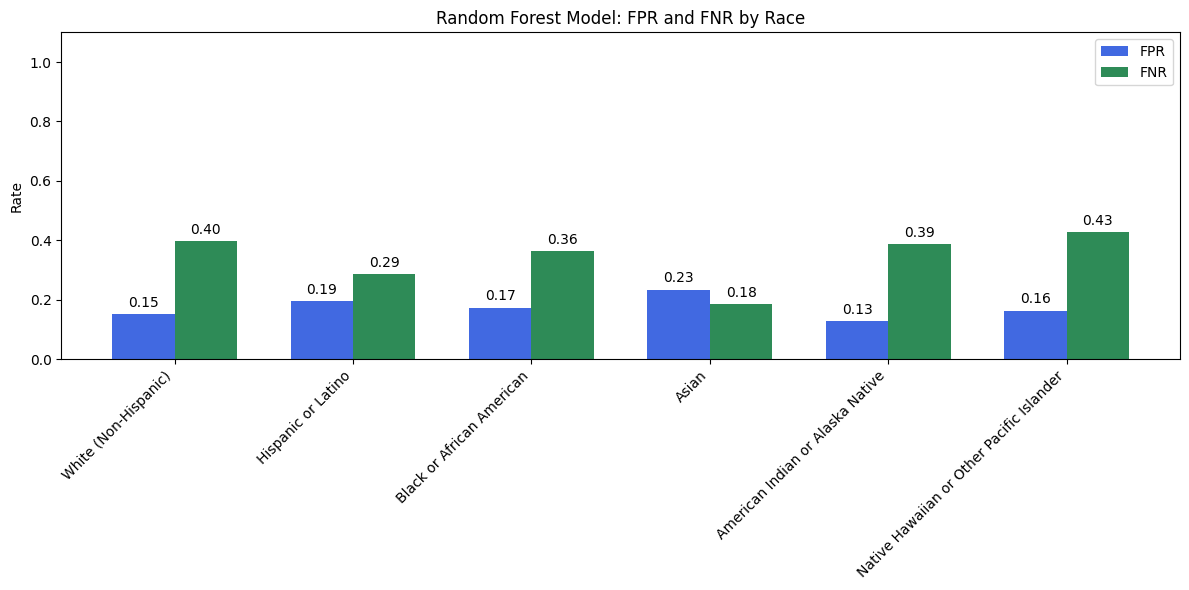

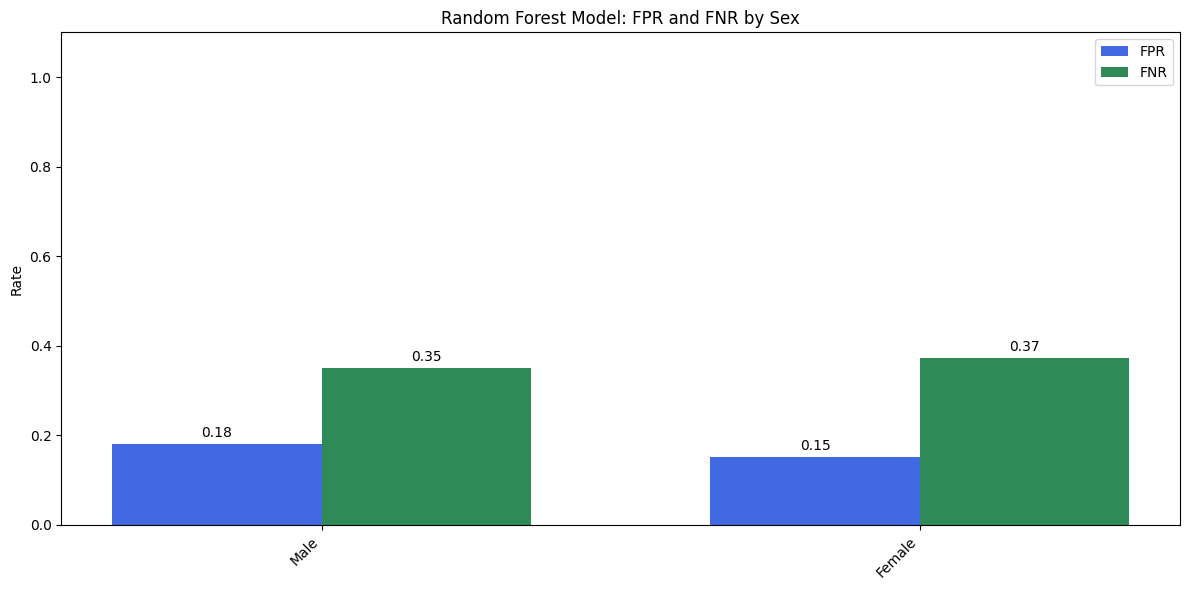

In [63]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

def group_metrics_for_plotting(pipeline, X, y, group_col):
    results = []

    X_ = X.copy()

    probs = pipeline.predict_proba(X)[:, 1]
    X_["pred"] = (probs >= 0.8).astype(int)

    # Add 'actual' and the group_col
    X_["actual"] = y.values

    # Ensure the demographic column exists in X_ for grouping
    if group_col not in X_.columns:
        X_[group_col] = df_model.loc[X.index, group_col]

    for group, gdf in X_.groupby(group_col, observed=False):
        if len(gdf) == 0:
            continue

        # Using labels=[0,1] ensures confusion_matrix always returns a 2x2 array
        # This replaces the complex shape-checking logic
        tn, fp, fn, tp = confusion_matrix(gdf['actual'], gdf['pred'], labels=[0, 1]).ravel()

        # Calculate FPR and FNR, handling division by zero
        fpr = fp / (fp + tn) if (fp + tn) != 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) != 0 else np.nan

        results.append({
            "group": group,
            "n": len(gdf),
            "FPR": fpr,
            "FNR": fnr,
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

def plot_fpr_fnr(df_metrics, title):
    # Ensure labels are strings for cleaner plotting
    labels = df_metrics['group'].astype(str)
    fpr_values = df_metrics['FPR']
    fnr_values = df_metrics['FNR']

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    rects1 = ax.bar(x - width/2, fpr_values, width, label='FPR', color='royalblue')
    rects2 = ax.bar(x + width/2, fnr_values, width, label='FNR', color='seagreen')

    ax.set_ylabel('Rate')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.legend()
    ax.set_ylim(0, 1.1) # Adjusted for label headroom

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            if not np.isnan(height):
                ax.annotate(f'{height:.2f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom')

    autolabel(rects1)
    autolabel(rects2)

    fig.tight_layout()
    plt.show()


# --- Generate and Plot for Random Forest Model ---

# Race Plot
race_metrics = group_metrics_for_plotting(rf_pipeline, X_test, y_test, group_col='race')
plot_fpr_fnr(race_metrics, 'Random Forest Model: FPR and FNR by Race')

# Sex Plot
sex_metrics = group_metrics_for_plotting(rf_pipeline, X_test, y_test, group_col='sex')
plot_fpr_fnr(sex_metrics, 'Random Forest Model: FPR and FNR by Sex')

This section continues the audit by asking whether the model would remain reliable after deployment.
We evaluate the following:
1. Generalization: Does the model perform similarly on training and test data?
2. Drift risk: Which input features may change after 2024?
3. Robustness: Does the model remain stable when important inputs change?
4. Subgroup reliability: Does performance degrade differently across protected or operational slices?

The goal is not only to report accuracy or AUC. In general, a model that performs well on average may still fail under distribution shift, subgroup variation, or stress conditions.

# Generalization Gap: Train vs. Test Performance

In [64]:
# Generalization Gap Audit

import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

model_name = "Random Forest Model"
model = rf_pipeline

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_prob = model.predict_proba(X_train)[:, 1]
test_prob = model.predict_proba(X_test)[:, 1]

# apply threshold (0.8)
train_pred = (train_prob >= 0.8).astype(int)
test_pred = (test_prob >= 0.8).astype(int)

generalization_gap_table = pd.DataFrame([
    {
        "dataset": "Train",
        "accuracy": accuracy_score(y_train, train_pred),
        "auc": roc_auc_score(y_train, train_prob),
        "log_loss": log_loss(y_train, train_prob)
    },
    {
        "dataset": "Test",
        "accuracy": accuracy_score(y_test, test_pred),
        "auc": roc_auc_score(y_test, test_prob),
        "log_loss": log_loss(y_test, test_prob)
    },
    {
        "dataset": "Train - Test Gap",
        "accuracy": accuracy_score(y_train, train_pred) - accuracy_score(y_test, test_pred),
        "auc": roc_auc_score(y_train, train_prob) - roc_auc_score(y_test, test_prob),
        "log_loss": log_loss(y_test, test_prob) - log_loss(y_train, train_prob)
    }
])

print("=== Generalization Gap: Random Forest Model ===")
display(generalization_gap_table.round(4))

=== Generalization Gap: Random Forest Model ===


,dataset,accuracy,auc,log_loss
0,Train,0.6901,0.8434,0.3904
1,Test,0.6898,0.8426,0.3915
2,Train - Test Gap,0.0004,0.0008,0.0010


In [65]:
# Permutation Importance Audit

import pandas as pd
from sklearn.inspection import permutation_importance

model_name = "Random Forest"
model = rf_pipeline

print(f"=== Permutation Importance: {model_name} ===")

result = permutation_importance(
    model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

rf_permutation_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values("importance_mean", ascending=False)

=== Permutation Importance: Random Forest ===


# Drift Risk: PSI on Key Input Features

In [66]:
# Drift Audit: PSI, KS Test, and Score Distribution Drift

import numpy as np
import pandas as pd
from scipy.stats import ks_2samp

def calculate_psi(expected, actual, buckets=10):
    expected = pd.Series(expected).replace([np.inf, -np.inf], np.nan).dropna()
    actual = pd.Series(actual).replace([np.inf, -np.inf], np.nan).dropna()

    if expected.nunique() <= 1 or actual.nunique() <= 1:
        return np.nan

    breakpoints = np.percentile(expected, np.linspace(0, 100, buckets + 1))
    breakpoints = np.unique(breakpoints)

    if len(breakpoints) < 3:
        return np.nan

    expected_counts = pd.cut(expected, bins=breakpoints, include_lowest=True).value_counts(sort=False)
    actual_counts = pd.cut(actual, bins=breakpoints, include_lowest=True).value_counts(sort=False)

    expected_pct = expected_counts / expected_counts.sum()
    actual_pct = actual_counts / actual_counts.sum()

    expected_pct = expected_pct.replace(0, 0.0001)
    actual_pct = actual_pct.replace(0, 0.0001)

    return ((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)).sum()


def interpret_psi(psi):
    if pd.isna(psi):
        return "Not available"
    elif psi < 0.10:
        return "Stable"
    elif psi < 0.25:
        return "Monitor"
    else:
        return "Retrain / investigate"


protected_or_audit_cols = [
    "race", "sex", "ethnicity", "age", "applicant_age",
    "derived_race", "derived_sex", "derived_ethnicity"
]

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

drift_features = [
    col for col in numeric_features
    if not any(audit_col.lower() in col.lower() for audit_col in protected_or_audit_cols)
    and X_train[col].nunique() > 2
]

drift_results = []

for feature in drift_features:
    train_values = X_train[feature].replace([np.inf, -np.inf], np.nan).dropna()
    test_values = X_test[feature].replace([np.inf, -np.inf], np.nan).dropna()

    psi_score = calculate_psi(train_values, test_values)
    ks_stat, ks_pvalue = ks_2samp(train_values, test_values)

    drift_results.append({
        "feature": feature,
        "psi": psi_score,
        "psi_interpretation": interpret_psi(psi_score),
        "ks_statistic": ks_stat,
        "ks_pvalue": ks_pvalue
    })

drift_table = pd.DataFrame(drift_results).sort_values("psi", ascending=False)

print("=== Input Feature Drift: PSI and KS Test ===")
display(drift_table.round(4))


# Score distribution drift: Random Forest only
model_name = "Random Forest Model"
model = rf_pipeline

train_scores = model.predict_proba(X_train)[:, 1]
test_scores = model.predict_proba(X_test)[:, 1]

score_psi = calculate_psi(train_scores, test_scores)
score_ks, score_ks_pvalue = ks_2samp(train_scores, test_scores)

score_drift_table = pd.DataFrame([{
    "model": model_name,
    "score_psi": score_psi,
    "score_psi_interpretation": interpret_psi(score_psi),
    "score_ks_statistic": score_ks,
    "score_ks_pvalue": score_ks_pvalue
}])

print("\n=== Score Distribution Drift: Random Forest Model ===")
display(score_drift_table.round(4))

print("\nInterpretation:")
if score_psi < 0.10:
    print("Model score distribution is stable between train and test.")
else:
    print("Potential score drift detected. Monitor model stability.")

=== Input Feature Drift: PSI and KS Test ===


,feature,psi,psi_interpretation,ks_statistic,ks_pvalue
1,property_value,0.0,Stable,0.0011,0.4286
0,income,0.0,Stable,0.0008,0.8176
2,debt_to_income_ratio,0.0,Stable,0.0006,0.9591
3,ffiec_msa_md_median_family_income,0.0,Stable,0.0007,0.8748



=== Score Distribution Drift: Random Forest Model ===


,model,score_psi,score_psi_interpretation,score_ks_statistic,score_ks_pvalue
0,Random Forest Model,0.0,Stable,0.0011,0.3914



Interpretation:
Model score distribution is stable between train and test.


# Calibration Reliability: Overall Model Calibration

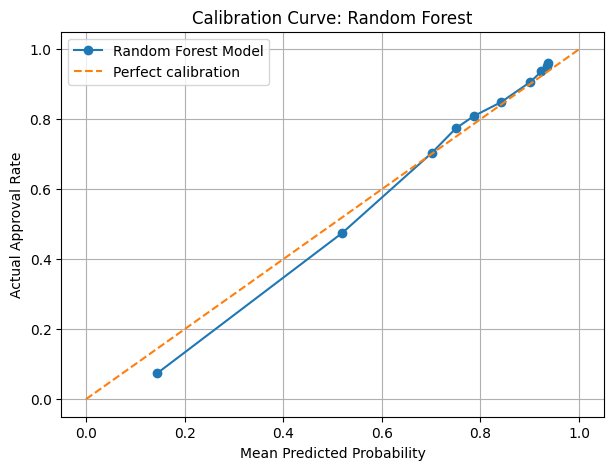

=== Calibration Reliability: Brier Score ===


,model,brier_score
0,Random Forest Model,0.1209


In [67]:
# Calibration Reliability: Overall Model Calibration

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

model_name = "Random Forest Model"
model = rf_pipeline

y_test_prob = model.predict_proba(X_test)[:, 1]

prob_true, prob_pred = calibration_curve(
    y_test,
    y_test_prob,
    n_bins=10,
    strategy="quantile"
)

brier = brier_score_loss(y_test, y_test_prob)

calibration_table = pd.DataFrame([{
    "model": model_name,
    "brier_score": brier
}])

plt.figure(figsize=(7, 5))
plt.plot(prob_pred, prob_true, marker="o", label=model_name)
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

plt.title("Calibration Curve: Random Forest")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Actual Approval Rate")
plt.legend()
plt.grid(True)
plt.show()

print("=== Calibration Reliability: Brier Score ===")
display(calibration_table.round(4))

# Calibration Reliability by Subgroup


=== Calibration by race: Random Forest Model ===


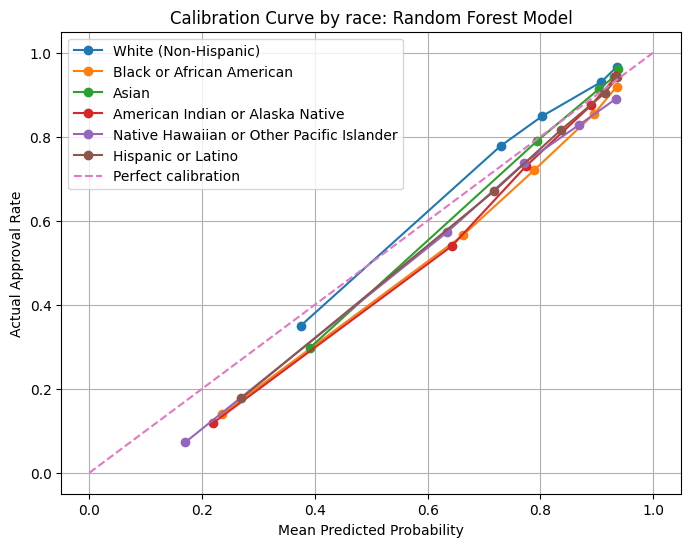

,model,group_column,group,n,brier_score
2,Random Forest Model,race,Asian,63915,0.0981
0,Random Forest Model,race,White (Non-Hispanic),489463,0.1148
5,Random Forest Model,race,Hispanic or Latino,121968,0.1272
3,Random Forest Model,race,American Indian or Alaska Native,9207,0.1432
4,Random Forest Model,race,Native Hawaiian or Other Pacific Islander,2769,0.1502
1,Random Forest Model,race,Black or African American,105171,0.1530



=== Calibration by sex: Random Forest Model ===


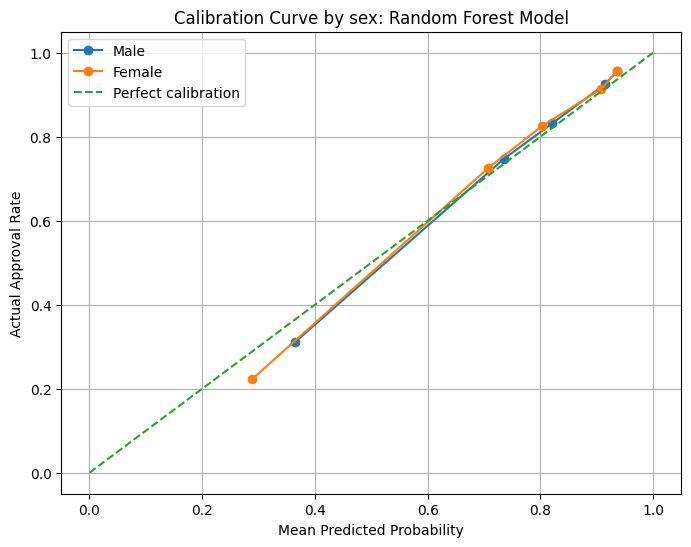

,model,group_column,group,n,brier_score
1,Random Forest Model,sex,Female,319725,0.1206
0,Random Forest Model,sex,Male,472768,0.1211


In [68]:
# Calibration Reliability by Subgroup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

model_name = "Random Forest Model"
model = rf_pipeline

source_df = df_model_loc if "df_model_loc" in globals() else df_model

required_group_cols = ["race", "sex"]
missing_cols = [col for col in required_group_cols if col not in source_df.columns]

if missing_cols:
    raise NameError(f"Missing subgroup columns in source_df: {missing_cols}")

y_test_prob = model.predict_proba(X_test)[:, 1]

calibration_audit = pd.DataFrame({
    "actual": y_test,
    "pred_prob": y_test_prob,
    "race": source_df.loc[X_test.index, "race"],
    "sex": source_df.loc[X_test.index, "sex"]
}, index=X_test.index)

for group_col in ["race", "sex"]:
    print(f"\n=== Calibration by {group_col}: {model_name} ===")

    plt.figure(figsize=(8, 6))

    subgroup_brier_results = []

    for group_name, group_df in calibration_audit.groupby(group_col):
        if len(group_df) < 100:
            continue

        prob_true, prob_pred = calibration_curve(
            group_df["actual"],
            group_df["pred_prob"],
            n_bins=5,
            strategy="quantile"
        )

        brier = brier_score_loss(
            group_df["actual"],
            group_df["pred_prob"]
        )

        subgroup_brier_results.append({
            "model": model_name,
            "group_column": group_col,
            "group": group_name,
            "n": len(group_df),
            "brier_score": brier
        })

        plt.plot(prob_pred, prob_true, marker="o", label=str(group_name))

    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.title(f"Calibration Curve by {group_col}: {model_name}")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Actual Approval Rate")
    plt.legend()
    plt.grid(True)
    plt.show()

    subgroup_brier_df = pd.DataFrame(subgroup_brier_results).sort_values(
        by="brier_score",
        ascending=True
    )

    display(subgroup_brier_df.round(4))

# Robustness / Stress Testing

In [69]:
# Robustness / Stress Testing
# Test sensitivity to income and debt-to-income changes

import numpy as np
import pandas as pd

model = rf_pipeline

baseline_prob = model.predict_proba(X_test)[:, 1]
baseline_mean_approval_prob = baseline_prob.mean()

stress_results = []

def run_stress_test(feature, multiplier, description):
    if feature not in X_test.columns:
        print(f"Skipping {feature}: not found in X_test")
        return

    X_stress = X_test.copy()
    X_stress[feature] = X_stress[feature] * multiplier

    stressed_prob = model.predict_proba(X_stress)[:, 1]
    stressed_mean = stressed_prob.mean()

    stress_results.append({
        "feature_stressed": feature,
        "stress_scenario": description,
        "baseline_mean_approval_probability": baseline_mean_approval_prob,
        "stressed_mean_approval_probability": stressed_mean,
        "change_in_mean_approval_probability": stressed_mean - baseline_mean_approval_prob,
        "absolute_change": abs(stressed_mean - baseline_mean_approval_prob)
    })


# Income stress: 10% and 20%
run_stress_test(
    feature="income",
    multiplier=0.90,
    description="Income decreased by 10%"
)

run_stress_test(
    feature="income",
    multiplier=0.80,
    description="Income decreased by 20%"
)

run_stress_test(
    feature="income",
    multiplier=1.10,
    description="Income increased by 10%"
)

run_stress_test(
    feature="income",
    multiplier=1.20,
    description="Income increased by 20%"
)


# Debt-to-income stress: 10% and 20%
run_stress_test(
    feature="debt_to_income_ratio",
    multiplier=1.10,
    description="Debt-to-income ratio increased by 10%"
)

run_stress_test(
    feature="debt_to_income_ratio",
    multiplier=1.20,
    description="Debt-to-income ratio increased by 20%"
)

run_stress_test(
    feature="debt_to_income_ratio",
    multiplier=0.90,
    description="Debt-to-income ratio decreased by 10%"
)

run_stress_test(
    feature="debt_to_income_ratio",
    multiplier=0.80,
    description="Debt-to-income ratio decreased by 20%"
)


stress_test_df = pd.DataFrame(stress_results).sort_values(
    by="absolute_change",
    ascending=False
)

display(stress_test_df.round(4))

print("\nInterpretation:")

top_change = stress_test_df.iloc[0]

if top_change["absolute_change"] < 0.01:
    print("Model predictions are relatively stable under stress scenarios.")
else:
    print("Model shows sensitivity to stressed features. Further investigation recommended.")

print("Note: Some income effects appear non-monotonic, suggesting interaction effects.")

,feature_stressed,stress_scenario,baseline_mean_approval_probability,stressed_mean_approval_probability,change_in_mean_approval_probability,absolute_change
3,income,Income increased by 20%,0.7441,0.7285,-0.0156,0.0156
1,income,Income decreased by 20%,0.7441,0.7520,0.0079,0.0079
2,income,Income increased by 10%,0.7441,0.7370,-0.0071,0.0071
0,income,Income decreased by 10%,0.7441,0.7488,0.0047,0.0047
7,debt_to_income_ratio,Debt-to-income ratio decreased by 20%,0.7441,0.7475,0.0034,0.0034
5,debt_to_income_ratio,Debt-to-income ratio increased by 20%,0.7441,0.7438,-0.0003,0.0003
6,debt_to_income_ratio,Debt-to-income ratio decreased by 10%,0.7441,0.7441,-0.0000,0.0000
4,debt_to_income_ratio,Debt-to-income ratio increased by 10%,0.7441,0.7441,-0.0000,0.0000



Interpretation:
Model shows sensitivity to stressed features. Further investigation recommended.
Note: Some income effects appear non-monotonic, suggesting interaction effects.


# ICE Curves: Sensitivity Analysis

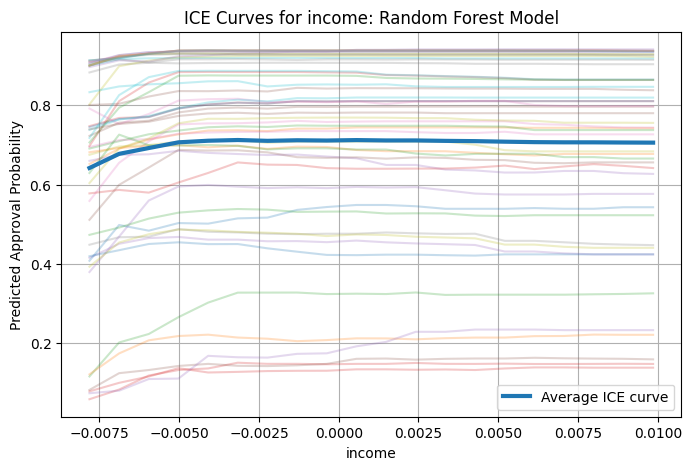

,feature,sample_size,grid_minimum,grid_maximum,average_prediction_range,maximum_prediction_range
0,income,50,-0.0078,0.0099,0.0776,0.2195


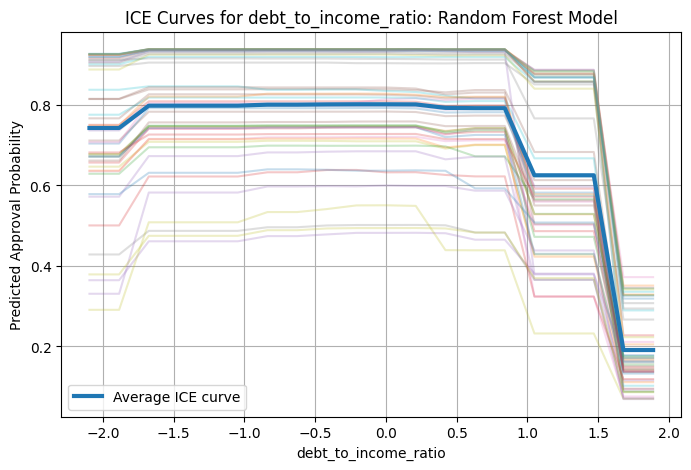

,feature,sample_size,grid_minimum,grid_maximum,average_prediction_range,maximum_prediction_range
0,debt_to_income_ratio,50,-2.0958,1.8897,0.6106,0.7562


=== ICE Sensitivity Summary: Random Forest Model ===


,feature,sample_size,grid_minimum,grid_maximum,average_prediction_range,maximum_prediction_range
0,income,50,-0.0078,0.0099,0.0776,0.2195
1,debt_to_income_ratio,50,-2.0958,1.8897,0.6106,0.7562


In [70]:
# ICE Curves: Sensitivity Analysis
# How predicted approval probability changes as one feature varies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_ice_curves(model, X, feature, sample_size=50, grid_points=20, random_state=42):
    if feature not in X.columns:
        print(f"Skipping {feature}: not found in X.")
        return None

    feature_values = pd.to_numeric(X[feature], errors="coerce")

    if feature_values.notna().sum() == 0:
        print(f"Skipping {feature}: feature is not numeric or has no valid values.")
        return None

    X_sample = X.sample(
        n=min(sample_size, len(X)),
        random_state=random_state
    ).copy()

    low = np.nanpercentile(feature_values, 5)
    high = np.nanpercentile(feature_values, 95)

    grid = np.linspace(low, high, grid_points)

    ice_curves = []

    for idx in X_sample.index:
        row_predictions = []

        for value in grid:
            X_temp = X_sample.loc[[idx]].copy()
            X_temp[feature] = value

            pred_prob = model.predict_proba(X_temp)[:, 1][0]
            row_predictions.append(pred_prob)

        ice_curves.append(row_predictions)

    ice_curves = np.array(ice_curves)

    prediction_range_per_row = ice_curves.max(axis=1) - ice_curves.min(axis=1)

    sensitivity_summary = pd.DataFrame([{
        "feature": feature,
        "sample_size": len(X_sample),
        "grid_minimum": low,
        "grid_maximum": high,
        "average_prediction_range": prediction_range_per_row.mean(),
        "maximum_prediction_range": prediction_range_per_row.max()
    }])

    plt.figure(figsize=(8, 5))

    for curve in ice_curves:
        plt.plot(grid, curve, alpha=0.25)

    plt.plot(
        grid,
        ice_curves.mean(axis=0),
        linewidth=3,
        label="Average ICE curve"
    )

    plt.title(f"ICE Curves for {feature}: Random Forest Model")
    plt.xlabel(feature)
    plt.ylabel("Predicted Approval Probability")
    plt.legend()
    plt.grid(True)
    plt.show()

    display(sensitivity_summary.round(4))

    return sensitivity_summary


model = rf_pipeline

ice_summaries = []

for feature in ["income", "debt_to_income_ratio"]:
    if feature in X_test.columns:
        summary = plot_ice_curves(
            model=model,
            X=X_test,
            feature=feature,
            sample_size=50,
            grid_points=20
        )

        if summary is not None:
            ice_summaries.append(summary)

if ice_summaries:
    ice_summary_df = pd.concat(ice_summaries, ignore_index=True)
    print("=== ICE Sensitivity Summary: Random Forest Model ===")
    display(ice_summary_df.round(4))
else:
    print("No available ICE features found in X_test.")

# Additional Drift and Feature-Reliance Checks

In [71]:
# Additional Drift Check: Simple MMD

import numpy as np
import pandas as pd

def simple_mmd_linear(X_a, X_b):
    """
    Simple linear-kernel MMD approximation.
    Measures distance between train and test mean feature vectors.
    Larger values suggest greater distribution difference.
    """
    X_a = np.asarray(X_a, dtype=float)
    X_b = np.asarray(X_b, dtype=float)

    mean_a = np.nanmean(X_a, axis=0)
    mean_b = np.nanmean(X_b, axis=0)

    return np.sum((mean_a - mean_b) ** 2)


protected_or_audit_cols = [
    "race", "sex", "ethnicity", "age", "applicant_age",
    "derived_race", "derived_sex", "derived_ethnicity"
]

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

mmd_features = [
    col for col in numeric_features
    if not any(audit_col.lower() in col.lower() for audit_col in protected_or_audit_cols)
    and X_train[col].nunique() > 2
]

X_train_mmd = (
    X_train[mmd_features]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(X_train[mmd_features].median())
)

X_test_mmd = (
    X_test[mmd_features]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(X_train[mmd_features].median())
)

mmd_score = simple_mmd_linear(X_train_mmd, X_test_mmd)

mmd_df = pd.DataFrame([{
    "feature_space": ", ".join(mmd_features),
    "simple_linear_mmd": mmd_score,
    "interpretation": "Lower values suggest train/test feature distributions are more similar"
}])

print("=== Additional Drift Check: Simple Linear MMD ===")
display(mmd_df.round(6))

=== Additional Drift Check: Simple Linear MMD ===


,feature_space,simple_linear_mmd,interpretation
0,"income, property_value, debt_to_income_ratio, ...",0.000001,Lower values suggest train/test feature distri...


# Slide-Based Evaluation

In [72]:
# Slice-Based Evaluation

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

model = rf_pipeline

source_df = df_model_loc if "df_model_loc" in globals() else df_model

slice_audit_df = pd.DataFrame({
    "actual": y_test,
    "pred": (model.predict_proba(X_test)[:, 1] >= 0.8).astype(int),
    "pred_prob": model.predict_proba(X_test)[:, 1],
    "race": source_df.loc[X_test.index, "race"],
    "sex": source_df.loc[X_test.index, "sex"]
}, index=X_test.index)

# Optional: age is used only for audit slicing, not as a model input.
if "applicant_age" in source_df.columns:
    slice_audit_df["applicant_age"] = source_df.loc[X_test.index, "applicant_age"]

# Optional: state code if available.
# Use only as an audit slice, not as a model input.
if "state_code" in source_df.columns:
    slice_audit_df["state_code"] = source_df.loc[X_test.index, "state_code"]


def compute_slice_metrics(df, group_col, min_n=100):
    rows = []

    for group_name, group_df in df.groupby(group_col):
        if len(group_df) < min_n:
            continue

        y_true = group_df["actual"]
        y_pred = group_df["pred"]
        y_prob = group_df["pred_prob"]

        # Skip if AUC cannot be calculated because only one class is present
        if y_true.nunique() < 2:
            auc = np.nan
        else:
            auc = roc_auc_score(y_true, y_prob)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        rows.append({
            "slice_column": group_col,
            "slice_group": group_name,
            "n": len(group_df),
            "accuracy": accuracy_score(y_true, y_pred),
            "auc": auc,
            "approval_rate": y_pred.mean(),
            "fpr": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "fnr": fn / (fn + tp) if (fn + tp) > 0 else np.nan
        })

    return pd.DataFrame(rows).sort_values("n", ascending=False)


slice_tables = []

for group_col in ["race", "sex"]:
    print(f"\n=== Slice-Based Evaluation by {group_col}: Random Forest ===")
    table = compute_slice_metrics(slice_audit_df, group_col)
    display(table.round(4))
    slice_tables.append(table)

if "applicant_age" in slice_audit_df.columns:
    print("\n=== Slice-Based Evaluation by applicant_age: Random Forest ===")
    age_table = compute_slice_metrics(slice_audit_df, "applicant_age")
    display(age_table.round(4))
    slice_tables.append(age_table)

if "state_code" in slice_audit_df.columns:
    print("\n=== Slice-Based Evaluation by state_code: Random Forest ===")
    state_table = compute_slice_metrics(slice_audit_df, "state_code", min_n=500)
    display(state_table.round(4))
    slice_tables.append(state_table)

slice_eval_df = pd.concat(slice_tables, ignore_index=True)


=== Slice-Based Evaluation by race: Random Forest ===


,slice_column,slice_group,n,accuracy,auc,approval_rate,fpr,fnr
0,race,White (Non-Hispanic),489463,0.6584,0.8385,0.5013,0.1512,0.3970
5,race,Hispanic or Latino,121968,0.7414,0.8522,0.5592,0.1947,0.2858
1,race,Black or African American,105171,0.7050,0.8349,0.4697,0.1733,0.3635
2,race,Asian,63915,0.8051,0.8689,0.6885,0.2339,0.1839
3,race,American Indian or Alaska Native,9207,0.7065,0.8574,0.4390,0.1272,0.3865
4,race,Native Hawaiian or Other Pacific Islander,2769,0.6728,0.8323,0.4171,0.1635,0.4275



=== Slice-Based Evaluation by sex: Random Forest ===


,slice_column,slice_group,n,accuracy,auc,approval_rate,fpr,fnr
0,sex,Male,472768,0.6915,0.8356,0.5349,0.1810,0.3499
1,sex,Female,319725,0.6872,0.8521,0.4982,0.1517,0.3728



=== Slice-Based Evaluation by applicant_age: Random Forest ===


,slice_column,slice_group,n,accuracy,auc,approval_rate,fpr,fnr
1,applicant_age,35-44,193019,0.7179,0.8429,0.5699,0.1972,0.3095
2,applicant_age,45-54,171023,0.6476,0.8241,0.4628,0.1649,0.4238
0,applicant_age,25-34,160332,0.8131,0.8654,0.7139,0.2438,0.1733
3,applicant_age,55-64,132282,0.6119,0.8233,0.3956,0.1300,0.4947
4,applicant_age,65-74,72813,0.5694,0.8203,0.3193,0.0951,0.5805
5,applicant_age,<25,33055,0.8555,0.8732,0.7684,0.2679,0.1161
6,applicant_age,>74,29969,0.5425,0.8185,0.2538,0.0697,0.6533



=== Slice-Based Evaluation by state_code: Random Forest ===


,slice_column,slice_group,n,accuracy,auc,approval_rate,fpr,fnr
9,state_code,FL,68860,0.7070,0.8349,0.5282,0.2019,0.3320
44,state_code,TX,65837,0.7788,0.8708,0.5999,0.1817,0.2366
4,state_code,CA,60626,0.6922,0.8375,0.5241,0.1882,0.3519
27,state_code,NC,34104,0.6838,0.8561,0.5044,0.1365,0.3751
35,state_code,OH,33356,0.6474,0.8367,0.4680,0.1322,0.4237
10,state_code,GA,32067,0.6911,0.8358,0.5216,0.1792,0.3555
38,state_code,PA,31929,0.6414,0.8320,0.4510,0.1334,0.4376
22,state_code,MI,28955,0.6437,0.8292,0.4738,0.1534,0.4222
34,state_code,NY,28527,0.6804,0.8298,0.4971,0.1830,0.3752
14,state_code,IL,28204,0.7312,0.8393,0.5893,0.2110,0.2876


## Monitoring and Governance Plan

The audit results show that the Random Forest model generalizes well within the 2024 HMDA train/test split and shows low PSI, KS, and MMD drift risk for the tested input features. The model is also mostly stable under 10% and 20% stress scenarios.
It is obvious from the results that the ICE curves show that `debt_to_income_ratio` has the strongest non-linear effect on predicted approval probabilities, while `income` has a weaker and less monotonic effect. This suggests the model may rely on threshold-like financial risk patterns.
From another perspective, the calibration results show that predicted probabilities are not perfectly aligned with actual approval rates.

In [73]:
# Monitoring and Governance Plan
# Purpose: Summarize what should be monitored if the Random Forest model were deployed.

import pandas as pd

monitoring_plan_df = pd.DataFrame([
    {
        "Monitoring Area": "Generalization",
        "Metric / Check": "Random Forest train-test gap in Accuracy, AUC, and Log Loss",
        "Why It Matters": "Detects whether model performance is degrading or overfitting."
    },
    {
        "Monitoring Area": "Drift",
        "Metric / Check": "PSI, KS test, MMD, and score distribution drift",
        "Why It Matters": "Detects whether future applicants or model scores differ from the training/test distribution."
    },
    {
        "Monitoring Area": "Calibration",
        "Metric / Check": "Calibration curve and Brier score",
        "Why It Matters": "Checks whether predicted probabilities match actual approval rates."
    },
    {
        "Monitoring Area": "Subgroup reliability",
        "Metric / Check": "Calibration and reliability checks by race and sex",
        "Why It Matters": "Prevents aggregate metrics from hiding subgroup-level performance problems."
    },
    {
        "Monitoring Area": "Robustness",
        "Metric / Check": "10% and 20% stress tests plus ICE curves for income and debt-to-income ratio",
        "Why It Matters": "Checks whether realistic input changes cause unstable predictions."
    },
    {
        "Monitoring Area": "Feature reliance",
        "Metric / Check": "Permutation importance",
        "Why It Matters": "Identifies which features the Random Forest model depends on most and which should be monitored closely."
    },
    {
        "Monitoring Area": "Governance",
        "Metric / Check": "Version control, audit logs, review triggers, and periodic retraining criteria",
        "Why It Matters": "Creates accountability and makes model updates defensible."
    }
])

display(monitoring_plan_df)

,Monitoring Area,Metric / Check,Why It Matters
0,Generalization,"Random Forest train-test gap in Accuracy, AUC,...",Detects whether model performance is degrading...
1,Drift,"PSI, KS test, MMD, and score distribution drift",Detects whether future applicants or model sco...
2,Calibration,Calibration curve and Brier score,Checks whether predicted probabilities match a...
3,Subgroup reliability,Calibration and reliability checks by race and...,Prevents aggregate metrics from hiding subgrou...
4,Robustness,10% and 20% stress tests plus ICE curves for i...,Checks whether realistic input changes cause u...
5,Feature reliance,Permutation importance,Identifies which features the Random Forest mo...
6,Governance,"Version control, audit logs, review triggers, ...",Creates accountability and makes model updates...


## Threat Model

Before evaluating ML security risk, we define the threat model. Ideally, a useful threat model should answer four questions:

1. Who is the adversary?
2. What do they know?
3. What can they control?
4. What is their goal?

## PGD-Style Evasion / Input Gaming Simulation

In [74]:
# PGD-Style Evasion / Input Gaming Simulation
# Purpose: Simulate deployment-time input manipulation for mutable HMDA features.

import numpy as np
import pandas as pd

model = rf_pipeline

baseline_prob = model.predict_proba(X_test)[:, 1]
baseline_pred = (baseline_prob >= 0.80).astype(int)

evasion_results = []

mutable_features = [
    "income",
    "debt_to_income_ratio"
]

# PGD-style bounded perturbation levels
epsilon_levels = [0.05, 0.10, 0.15, 0.20, 0.25]

for epsilon in epsilon_levels:
    X_adv = X_test.copy()

    # Input-gaming direction:
    # Increase income and decrease debt-to-income ratio within epsilon bounds.
    if "income" in X_adv.columns:
        X_adv["income"] = X_adv["income"] * (1 + epsilon)

    if "debt_to_income_ratio" in X_adv.columns:
        X_adv["debt_to_income_ratio"] = X_adv["debt_to_income_ratio"] * (1 - epsilon)

    adv_prob = model.predict_proba(X_adv)[:, 1]
    adv_pred = (adv_prob >= 0.80).astype(int)

    evasion_results.append({
        "attack_type": "PGD-style bounded input gaming",
        "epsilon": epsilon,
        "manipulated_features": ", ".join([f for f in mutable_features if f in X_adv.columns]),
        "baseline_mean_approval_probability": baseline_prob.mean(),
        "adversarial_mean_approval_probability": adv_prob.mean(),
        "change_in_mean_approval_probability": adv_prob.mean() - baseline_prob.mean(),
        "baseline_predicted_approval_rate": baseline_pred.mean(),
        "adversarial_predicted_approval_rate": adv_pred.mean(),
        "change_in_predicted_approval_rate": adv_pred.mean() - baseline_pred.mean(),
        "number_of_prediction_flips": int((baseline_pred != adv_pred).sum())
    })

pgd_evasion_df = pd.DataFrame(evasion_results)

print("=== PGD-Style Evasion / Input Gaming Results: Random Forest Model ===")
display(pgd_evasion_df.round(4))

=== PGD-Style Evasion / Input Gaming Results: Random Forest Model ===


,attack_type,epsilon,manipulated_features,baseline_mean_approval_probability,adversarial_mean_approval_probability,change_in_mean_approval_probability,baseline_predicted_approval_rate,adversarial_predicted_approval_rate,change_in_predicted_approval_rate,number_of_prediction_flips
0,PGD-style bounded input gaming,0.05,"income, debt_to_income_ratio",0.7441,0.7405,-0.0036,0.5201,0.5153,-0.0048,4307
1,PGD-style bounded input gaming,0.10,"income, debt_to_income_ratio",0.7441,0.7370,-0.0071,0.5201,0.5100,-0.0101,8640
2,PGD-style bounded input gaming,0.15,"income, debt_to_income_ratio",0.7441,0.7332,-0.0109,0.5201,0.5045,-0.0156,13843
3,PGD-style bounded input gaming,0.20,"income, debt_to_income_ratio",0.7441,0.7322,-0.0119,0.5201,0.5008,-0.0193,20993
4,PGD-style bounded input gaming,0.25,"income, debt_to_income_ratio",0.7441,0.7783,0.0342,0.5201,0.5210,0.0009,30029


## Label-Flip Poisoning Sensitivity Test

In [75]:
# Label-Flip Poisoning Sensitivity Test

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

model = rf_pipeline

# Use filtered audit column only
source_df = df_model_loc if "df_model_loc" in globals() else df_model

if "race" not in source_df.columns:
    raise NameError("The source dataframe must contain the filtered audit column: race")

group_train = source_df.loc[X_train.index, "race"]
group_test = source_df.loc[X_test.index, "race"]

# Prefer Black or African American as target group if available
group_counts = group_train.value_counts()
target_group = group_counts.index[0]

for group_name in group_counts.index:
    if "black" in str(group_name).lower():
        target_group = group_name
        break

print("Target group for label-flip simulation:", target_group)


def approval_rate_by_group(y_pred, groups, target_group):
    groups = pd.Series(groups).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)

    target_mask = groups == target_group
    other_mask = groups != target_group

    target_rate = y_pred[target_mask].mean() if target_mask.sum() > 0 else np.nan
    other_rate = y_pred[other_mask].mean() if other_mask.sum() > 0 else np.nan

    return target_rate, other_rate


def safe_air(target_rate, other_rate):
    if pd.isna(target_rate) or pd.isna(other_rate):
        return np.nan
    if max(target_rate, other_rate) == 0:
        return np.nan
    return min(target_rate, other_rate) / max(target_rate, other_rate)


def poison_labels(y_train, group_train, target_group, poison_rate=0.05, seed=42):
    rng = np.random.default_rng(seed)

    y_poisoned = pd.Series(y_train).copy().reset_index(drop=True)
    groups = pd.Series(group_train).reset_index(drop=True)

    candidates = np.where((groups == target_group) & (y_poisoned == 1))[0]
    n_flip = int(len(candidates) * poison_rate)

    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_poisoned.iloc[flip_idx] = 0

    return y_poisoned.values, n_flip


# Baseline model metrics
baseline_prob = model.predict_proba(X_test)[:, 1]
baseline_pred = (baseline_prob >= 0.80).astype(int)

baseline_auc = roc_auc_score(y_test, baseline_prob)
baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_logloss = log_loss(y_test, baseline_prob)

baseline_target_rate, baseline_other_rate = approval_rate_by_group(
    baseline_pred,
    group_test,
    target_group
)

baseline_air = safe_air(baseline_target_rate, baseline_other_rate)


# Poisoning sweep
poison_rates = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20]
poison_results = []

for rate in poison_rates:
    y_train_poisoned, n_flipped = poison_labels(
        y_train=y_train,
        group_train=group_train,
        target_group=target_group,
        poison_rate=rate,
        seed=42
    )

    poisoned_model = clone(model)
    poisoned_model.fit(X_train, y_train_poisoned)

    poison_prob = poisoned_model.predict_proba(X_test)[:, 1]
    poison_pred = (poison_prob >= 0.80).astype(int)

    auc = roc_auc_score(y_test, poison_prob)
    accuracy = accuracy_score(y_test, poison_pred)
    ll = log_loss(y_test, poison_prob)

    target_rate, other_rate = approval_rate_by_group(
        poison_pred,
        group_test,
        target_group
    )

    air_value = safe_air(target_rate, other_rate)

    poison_results.append({
        "poison_rate": rate,
        "labels_flipped": n_flipped,
        "auc": auc,
        "delta_auc": auc - baseline_auc,
        "accuracy": accuracy,
        "delta_accuracy": accuracy - baseline_accuracy,
        "log_loss": ll,
        "delta_log_loss": ll - baseline_logloss,
        f"predicted_approval_rate_{target_group}": target_rate,
        "predicted_approval_rate_other_groups": other_rate,
        "air_style_ratio": air_value,
        "delta_air_style_ratio": air_value - baseline_air
    })

poison_df = pd.DataFrame(poison_results)

print("=== Label-Flip Poisoning Sensitivity Test: Random Forest Model ===")
display(poison_df.round(4))

Target group for label-flip simulation: Black or African American
=== Label-Flip Poisoning Sensitivity Test: Random Forest Model ===


,poison_rate,labels_flipped,auc,delta_auc,accuracy,delta_accuracy,log_loss,delta_log_loss,predicted_approval_rate_Black or African American,predicted_approval_rate_other_groups,air_style_ratio,delta_air_style_ratio
0,0.00,0,0.8426,0.0000,0.6898,0.0000,0.3915,0.0000,0.4697,0.5278,0.8899,0.0000
1,0.02,5385,0.8430,0.0004,0.6828,-0.0070,0.3914,-0.0000,0.4586,0.5167,0.8876,-0.0023
2,0.05,13463,0.8426,-0.0001,0.6823,-0.0074,0.3928,0.0013,0.4571,0.5160,0.8858,-0.0041
3,0.08,21541,0.8429,0.0003,0.6823,-0.0075,0.3919,0.0004,0.4558,0.5162,0.8831,-0.0068
4,0.10,26927,0.8430,0.0003,0.6796,-0.0101,0.3927,0.0012,0.4519,0.5119,0.8827,-0.0072
5,0.15,40390,0.8430,0.0004,0.6684,-0.0213,0.3933,0.0018,0.4368,0.4946,0.8832,-0.0067
6,0.20,53854,0.8433,0.0006,0.6671,-0.0227,0.3930,0.0016,0.4323,0.4927,0.8774,-0.0125


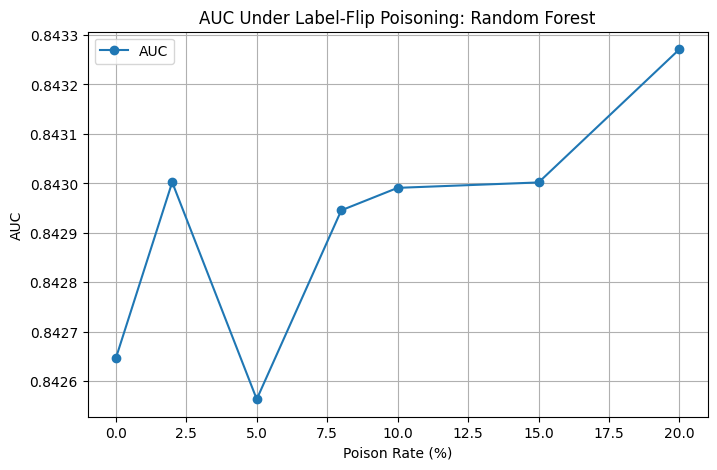

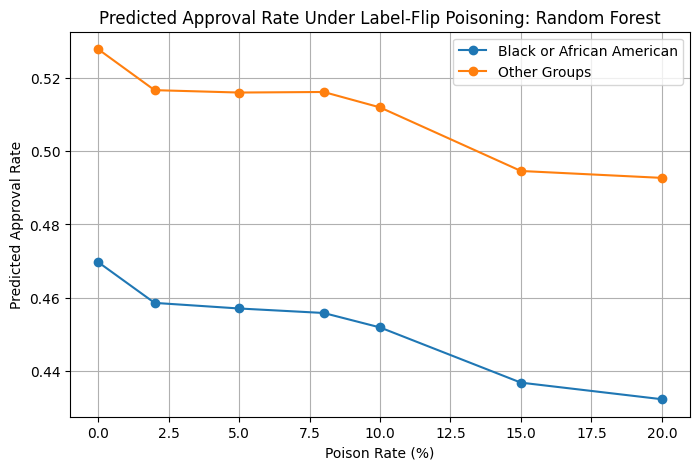

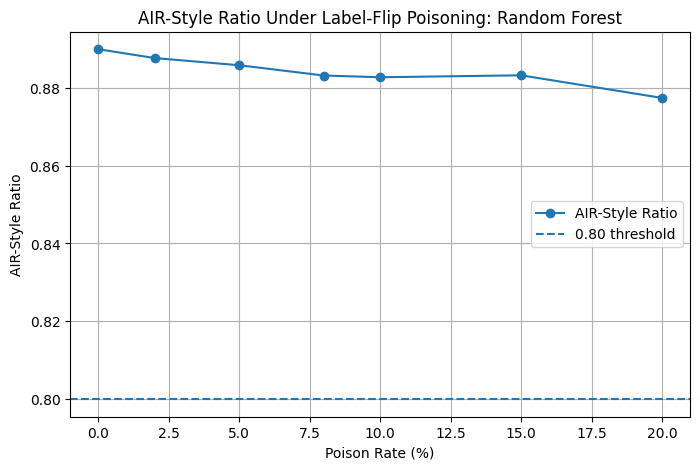

In [76]:
# Label-Flip Poisoning Visualization
# Purpose: Show how AUC, approval rates, and AIR-style ratio change as poison rate increases.

import matplotlib.pyplot as plt

x_pct = poison_df["poison_rate"] * 100

target_rate_col = [col for col in poison_df.columns if col.startswith("predicted_approval_rate_") and col != "predicted_approval_rate_other_groups"][0]

plt.figure(figsize=(8, 5))
plt.plot(x_pct, poison_df["auc"], marker="o", label="AUC")
plt.xlabel("Poison Rate (%)")
plt.ylabel("AUC")
plt.title("AUC Under Label-Flip Poisoning: Random Forest")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    x_pct,
    poison_df[target_rate_col],
    marker="o",
    label=target_rate_col.replace("predicted_approval_rate_", "")
)
plt.plot(
    x_pct,
    poison_df["predicted_approval_rate_other_groups"],
    marker="o",
    label="Other Groups"
)
plt.xlabel("Poison Rate (%)")
plt.ylabel("Predicted Approval Rate")
plt.title("Predicted Approval Rate Under Label-Flip Poisoning: Random Forest")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(x_pct, poison_df["air_style_ratio"], marker="o", label="AIR-Style Ratio")
plt.axhline(0.80, linestyle="--", label="0.80 threshold")
plt.xlabel("Poison Rate (%)")
plt.ylabel("AIR-Style Ratio")
plt.title("AIR-Style Ratio Under Label-Flip Poisoning: Random Forest")
plt.grid(True)
plt.legend()
plt.show()

## Membership Inference Privacy Check

In [77]:
# Membership Inference Privacy Check

import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score

model = rf_pipeline

# 1. Get model confidence on train and test records
train_prob_matrix = model.predict_proba(X_train)
test_prob_matrix = model.predict_proba(X_test)

train_confidence = train_prob_matrix.max(axis=1)
test_confidence = test_prob_matrix.max(axis=1)

# 2. Build simple membership inference dataset
mi_labels = np.concatenate([
    np.ones(len(train_confidence)),
    np.zeros(len(test_confidence))
])

mi_scores = np.concatenate([
    train_confidence,
    test_confidence
])

mi_auc = roc_auc_score(mi_labels, mi_scores)
confidence_gap = train_confidence.mean() - test_confidence.mean()

# 3. Connect membership inference risk to generalization gap
train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
generalization_gap_auc = train_auc - test_auc

membership_summary_df = pd.DataFrame([
    {
        "model": "Random Forest",
        "train_mean_confidence": train_confidence.mean(),
        "test_mean_confidence": test_confidence.mean(),
        "confidence_gap": confidence_gap,
        "membership_inference_auc": mi_auc,
        "train_auc": train_auc,
        "test_auc": test_auc,
        "auc_generalization_gap": generalization_gap_auc
    }
])

print("=== Membership Inference Privacy Check: Random Forest Model ===")
display(membership_summary_df.round(4))

=== Membership Inference Privacy Check: Random Forest Model ===


,model,train_mean_confidence,test_mean_confidence,confidence_gap,membership_inference_auc,train_auc,test_auc,auc_generalization_gap
0,Random Forest,0.8193,0.8193,-0.0,0.5001,0.8434,0.8426,0.0008


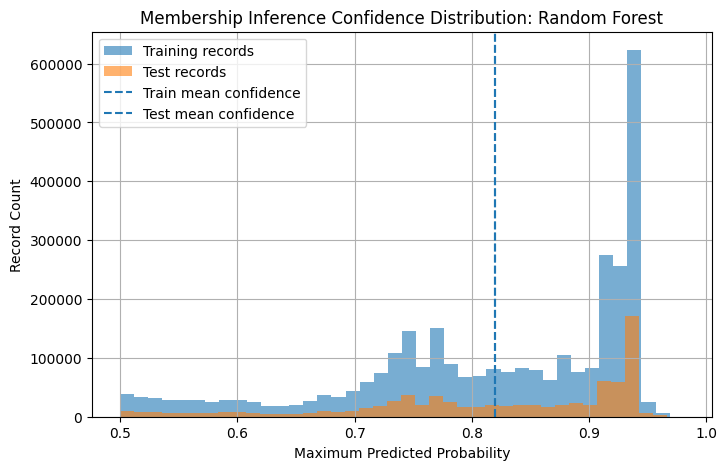

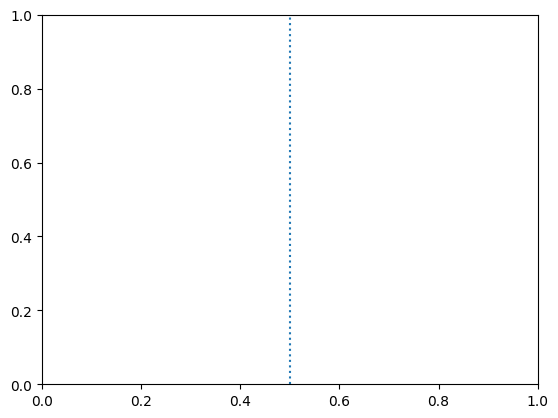

In [78]:
# Membership Inference Confidence Visualization
# Purpose: Compare Random Forest confidence on training members vs. test non-members.

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(train_confidence, bins=40, alpha=0.6, label="Training records")
plt.hist(test_confidence, bins=40, alpha=0.6, label="Test records")

plt.axvline(
    train_confidence.mean(),
    linestyle="--",
    label="Train mean confidence"
)

plt.axvline(
    test_confidence.mean(),
    linestyle="--",
    label="Test mean confidence"
)

plt.title("Membership Inference Confidence Distribution: Random Forest")
plt.xlabel("Maximum Predicted Probability")
plt.ylabel("Record Count")
plt.legend()
plt.grid(True)
plt.show()
plt.axvline(0.5, linestyle=":", label="Random confidence baseline")